# Notebook 04 — Centroid Analysis: Cross-Framework Δ Scores

Implements the centroid-based representation analysis from the experiment plan.

**Pipeline:**
1. Load mode-A hidden states (memory-mapped, float16)
2. Train/test split by `attempt` (test = attempt 10)
3. Build centroids per source: harmfulness direction v_harmful, mu_harmful, mu_harmless, mu_refuse, mu_accept
4. Compute Δ_harmful and Δ_refuse for every test conversation under every centroid source
5. Evaluate cross-framework generalisation (accuracy matrix)
6. Reproduce Zhao et al. Figure 5 scatter for multi-turn conversations
7. Analyse direction cosine similarities across sources
8. Layer-wise accuracy curves

**Data:** `results/representations/mode_a/`  
**Centroids saved to:** `results/centroids/`

## Section 1: Setup & Load

In [51]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

REPR_ROOT    = repo_root / "results" / "representations" / "mode_a"
CENTROID_DIR = repo_root / "results" / "centroids"
CENTROID_DIR.mkdir(parents=True, exist_ok=True)

FRAMEWORKS   = ["crescendo", "actorattack", "xteaming"]
SOURCES      = FRAMEWORKS + ["single_turn"]
N_LAYERS     = 32
HIDDEN_DIM   = 4096

# Consistent colour palette
FW_PALETTE = {
    "crescendo":   "#4C72B0",
    "actorattack": "#DD8452",
    "xteaming":    "#55A868",
    "single_turn": "#C44E52",
}
VERDICT_PALETTE = {
    "jailbroken": "#d62728",
    "near_miss":  "#ff7f0e",
    "refusal":    "#2ca02c",
    "benign":     "#9467bd",
}

print("Imports OK")
print(f"repo_root:    {repo_root}")
print(f"REPR_ROOT:    {REPR_ROOT}")
print(f"CENTROID_DIR: {CENTROID_DIR}")

Imports OK
repo_root:    /Users/lisahusieva/Desktop/multi-turn-rep-eng
REPR_ROOT:    /Users/lisahusieva/Desktop/multi-turn-rep-eng/results/representations/mode_a
CENTROID_DIR: /Users/lisahusieva/Desktop/multi-turn-rep-eng/results/centroids


In [52]:
# ── Load all folders with memory-mapped numpy ─────────────────────────────────
# Each entry: {"meta": DataFrame, "h_inst": mmap, "h_post_inst": mmap}

data = {}

for fw in FRAMEWORKS:
    for goal_type in ("harmful", "benign"):
        key    = f"{fw}_{goal_type}"
        folder = REPR_ROOT / key
        if not folder.exists():
            print(f"  MISSING: {key}")
            continue
        meta       = pd.read_parquet(folder / "metadata.parquet")
        h_inst     = np.load(str(folder / "h_inst.npy"),     mmap_mode="r")
        h_post_inst= np.load(str(folder / "h_post_inst.npy"),mmap_mode="r")
        data[key]  = {"meta": meta, "h_inst": h_inst, "h_post_inst": h_post_inst}
        print(f"  {key:30s}  n={len(meta):5d}  h_inst={h_inst.shape}  dtype={h_inst.dtype}")

# Single-turn (no attempt column; just pair_id)
for goal_type in ("harmful", "benign"):
    key    = f"single_turn_{goal_type}"
    folder = REPR_ROOT / key
    if not folder.exists():
        print(f"  MISSING: {key}")
        continue
    meta       = pd.read_parquet(folder / "metadata.parquet")
    h_inst     = np.load(str(folder / "h_inst.npy"),     mmap_mode="r")
    h_post_inst= np.load(str(folder / "h_post_inst.npy"),mmap_mode="r")
    data[key]  = {"meta": meta, "h_inst": h_inst, "h_post_inst": h_post_inst}
    print(f"  {key:30s}  n={len(meta):5d}  h_inst={h_inst.shape}  dtype={h_inst.dtype}")

print("\nAll folders loaded.")

  crescendo_harmful               n=  979  h_inst=(979, 32, 4096)  dtype=float16
  crescendo_benign                n=  967  h_inst=(967, 32, 4096)  dtype=float16
  actorattack_harmful             n=  999  h_inst=(999, 32, 4096)  dtype=float16
  actorattack_benign              n= 1000  h_inst=(1000, 32, 4096)  dtype=float16
  xteaming_harmful                n=  970  h_inst=(970, 32, 4096)  dtype=float16
  xteaming_benign                 n= 1000  h_inst=(1000, 32, 4096)  dtype=float16
  single_turn_harmful             n=  100  h_inst=(100, 32, 4096)  dtype=float16
  single_turn_benign              n=  100  h_inst=(100, 32, 4096)  dtype=float16

All folders loaded.


In [53]:
# ── Build per-framework combined dataframe ────────────────────────────────────
# Adds a global integer index into the per-folder arrays.

fw_dfs = {}   # framework -> combined DataFrame (harmful + benign)

for fw in FRAMEWORKS:
    parts = []
    for goal_type in ("harmful", "benign"):
        key = f"{fw}_{goal_type}"
        if key not in data:
            continue
        meta = data[key]["meta"].copy()
        meta["_key"]  = key        # which folder to look up
        meta["_idx"]  = np.arange(len(meta))   # row index in that folder's arrays
        parts.append(meta)
    df = pd.concat(parts, ignore_index=True)
    fw_dfs[fw] = df
    n_harmful = (df["goal_type"] == "harmful").sum()
    n_benign  = (df["goal_type"] == "benign").sum()
    print(f"  {fw:15s}  total={len(df):5d}  harmful={n_harmful:5d}  benign={n_benign:5d}")

# Single-turn
st_parts = []
for goal_type in ("harmful", "benign"):
    key = f"single_turn_{goal_type}"
    if key not in data:
        continue
    meta = data[key]["meta"].copy()
    meta["_key"] = key
    meta["_idx"] = np.arange(len(meta))
    st_parts.append(meta)
st_df = pd.concat(st_parts, ignore_index=True)
print(f"  {'single_turn':15s}  total={len(st_df):5d}")

print("\nCombined dataframes ready.")

  crescendo        total= 1946  harmful=  979  benign=  967
  actorattack      total= 1999  harmful=  999  benign= 1000
  xteaming         total= 1970  harmful=  970  benign= 1000
  single_turn      total=  200

Combined dataframes ready.


## Section 2: Train / Test Split

- **Test:** `attempt == 10`
- **Train:** `attempt < 10`

Crescendo pairs with max attempt < 10 contribute to train only (no test sample for those pairs).
Single-turn has no attempt column — used entirely for centroid construction (no held-out split needed).

In [54]:
# ── Assign train/test masks per framework ─────────────────────────────────────

fw_train = {}
fw_test  = {}

for fw in FRAMEWORKS:
    df = fw_dfs[fw]
    train_mask = df["attempt"] < 10
    test_mask  = df["attempt"] == 10
    fw_train[fw] = df[train_mask].reset_index(drop=True)
    fw_test[fw]  = df[test_mask].reset_index(drop=True)
    print(f"  {fw:15s}  train={train_mask.sum():5d}  test={test_mask.sum():5d}  "
          f"  (pairs with no test: {df.loc[train_mask,'pair_id'].nunique() - df.loc[test_mask,'pair_id'].nunique()})")

print("\nSplit complete.")

  crescendo        train= 1751  test=  195    (pairs with no test: 0)
  actorattack      train= 1799  test=  200    (pairs with no test: 0)
  xteaming         train= 1773  test=  197    (pairs with no test: 0)

Split complete.


## Section 3: Centroid Construction

For each source (crescendo / actorattack / xteaming / single_turn):

- **v_harmful** (32, 4096): topic-cancelled harmfulness direction
- **mu_harmful** (32, 4096): mean h_inst over harmful train conversations
- **mu_harmless** (32, 4096): mean h_inst over benign accepted train conversations
- **mu_refuse** (32, 4096): mean h_post_inst over refused train conversations
- **mu_accept** (32, 4096): mean h_post_inst over accepted train conversations

For `single_turn`: no verdict column — skip mu_refuse / mu_accept.

In [55]:
# ── Helper: fetch hidden states for a subset of rows ─────────────────────────

def get_h(rows_df, kind="h_inst"):
    """
    rows_df: subset of a combined framework DataFrame (must have _key, _idx columns).
    kind: 'h_inst' or 'h_post_inst'
    Returns float32 array of shape (n, 32, 4096).
    """
    parts = []
    for key, group in rows_df.groupby("_key"):
        arr = data[key][kind]            # mmap (N, 32, 4096) float16
        idx = group["_idx"].values
        chunk = arr[idx].astype(np.float32)   # (m, 32, 4096) float32
        parts.append(chunk)
    if not parts:
        return np.zeros((0, N_LAYERS, HIDDEN_DIM), dtype=np.float32)
    return np.concatenate(parts, axis=0)  # (n, 32, 4096) float32


def mean_h(rows_df, kind="h_inst"):
    """Mean over all rows. Returns (32, 4096) float32."""""
    h = get_h(rows_df, kind)
    if len(h) == 0:
        return np.zeros((N_LAYERS, HIDDEN_DIM), dtype=np.float32)
    return h.mean(axis=0)   # (32, 4096)


print("Helper functions defined.")

Helper functions defined.


In [56]:
# ── v_harmful: topic-cancelled harmfulness direction ─────────────────────────
# For each source, compute per-goal deltas and average across goals.

def compute_v_harmful(train_df, source_name):
    """
    train_df: combined train DataFrame for the source.
    source_name: for logging.
    Returns v_harmful (32, 4096) float32.
    """
    v = np.zeros((N_LAYERS, HIDDEN_DIM), dtype=np.float32)
    n_pairs = 0

    all_pair_ids = train_df["pair_id"].unique()
    for k in sorted(all_pair_ids):
        harm_rows = train_df[(train_df["pair_id"] == k) & (train_df["goal_type"] == "harmful")]
        ben_rows  = train_df[(train_df["pair_id"] == k) & (train_df["goal_type"] == "benign")]
        if len(harm_rows) == 0 or len(ben_rows) == 0:
            continue
        mu_h = mean_h(harm_rows, "h_inst")   # (32, 4096)
        mu_b = mean_h(ben_rows,  "h_inst")   # (32, 4096)
        v += (mu_h - mu_b)
        n_pairs += 1

    if n_pairs > 0:
        v /= n_pairs
    print(f"  {source_name}: v_harmful computed from {n_pairs} goal pairs  norm_l16={np.linalg.norm(v[15]):.4f}")
    return v


# ── Build centroids for all sources ──────────────────────────────────────────

centroids = {}   # source -> dict of centroid arrays

for fw in FRAMEWORKS:
    train_df = fw_train[fw]
    c = {}

    # Behavioral subsets
    # Harmful: use verdict — near_miss counts as refusal (not a successful jailbreak)
    # Benign: use final_turn_outcome — verdict semantics differ for benign goals
    harmful_rows  = train_df[train_df["goal_type"] == "harmful"]
    benign_rows   = train_df[train_df["goal_type"] == "benign"]
    refused_harm  = train_df[(train_df["goal_type"] == "harmful")  & (train_df["verdict"].isin(["refusal", "near_miss"]))]
    accepted_harm = train_df[(train_df["goal_type"] == "harmful")  & (train_df["verdict"] == "jailbroken")]
    accepted_ben  = train_df[(train_df["goal_type"] == "benign")   & (train_df["final_turn_outcome"] == "accepted")]
    refused_ben   = train_df[(train_df["goal_type"] == "benign")   & (train_df["final_turn_outcome"] == "refused")]

    print(f"\n{fw}:")
    print(f"  refused_harmful={len(refused_harm)}  accepted_harmful={len(accepted_harm)}")
    print(f"  accepted_benign={len(accepted_ben)}  refused_benign={len(refused_ben)}")

    # v_harmful (topic-cancelled)
    c["v_harmful"] = compute_v_harmful(train_df, fw)

    # mu_harmful = mean h_inst over all harmful train
    all_harmful_rows = pd.concat([refused_harm, accepted_harm])
    c["mu_harmful"]  = mean_h(all_harmful_rows, "h_inst")

    # mu_harmless = mean h_inst over accepted benign train
    c["mu_harmless"] = mean_h(accepted_ben, "h_inst")

    # mu_refuse = mean h_post_inst over (refused_harmful + refused_benign)
    refused_all     = pd.concat([refused_harm, refused_ben])
    c["mu_refuse"]  = mean_h(refused_all, "h_post_inst")

    # mu_accept = mean h_post_inst over (accepted_harmful + accepted_benign)
    accepted_all    = pd.concat([accepted_harm, accepted_ben])
    c["mu_accept"]  = mean_h(accepted_all, "h_post_inst")

    centroids[fw] = c
    print(f"  Centroids built: {list(c.keys())}")


# ── single_turn centroids ─────────────────────────────────────────────────────
print("\nsingle_turn:")
c = {}
c["v_harmful"]  = compute_v_harmful(st_df, "single_turn")
harm_st = st_df[st_df["goal_type"] == "harmful"]
ben_st  = st_df[st_df["goal_type"] == "benign"]
c["mu_harmful"]  = mean_h(harm_st,  "h_inst")
c["mu_harmless"] = mean_h(ben_st,   "h_inst")
# No verdict for single_turn — skip mu_refuse / mu_accept
c["mu_refuse"]   = None
c["mu_accept"]   = None
centroids["single_turn"] = c
print(f"  Centroids built: {[k for k, v in c.items() if v is not None]}")

print("\nAll centroids constructed.")


crescendo:
  refused_harmful=153  accepted_harmful=727
  accepted_benign=862  refused_benign=9
  crescendo: v_harmful computed from 100 goal pairs  norm_l16=1.5545
  Centroids built: ['v_harmful', 'mu_harmful', 'mu_harmless', 'mu_refuse', 'mu_accept']

actorattack:
  refused_harmful=640  accepted_harmful=259
  accepted_benign=884  refused_benign=16
  actorattack: v_harmful computed from 100 goal pairs  norm_l16=1.1381
  Centroids built: ['v_harmful', 'mu_harmful', 'mu_harmless', 'mu_refuse', 'mu_accept']

xteaming:
  refused_harmful=329  accepted_harmful=544
  accepted_benign=880  refused_benign=20
  xteaming: v_harmful computed from 100 goal pairs  norm_l16=0.8237
  Centroids built: ['v_harmful', 'mu_harmful', 'mu_harmless', 'mu_refuse', 'mu_accept']

single_turn:
  single_turn: v_harmful computed from 100 goal pairs  norm_l16=1.6402
  Centroids built: ['v_harmful', 'mu_harmful', 'mu_harmless']

All centroids constructed.


In [57]:
# ── Save centroids ────────────────────────────────────────────────────────────

for source, c in centroids.items():
    save_dict = {}
    for key, val in c.items():
        if val is not None:
            save_dict[key] = torch.tensor(val)   # (32, 4096) float32
    path = CENTROID_DIR / f"{source}_centroids.pt"
    torch.save(save_dict, path)
    print(f"  Saved: {path}  keys={list(save_dict.keys())}")

print("\nCentroids saved to", CENTROID_DIR)

  Saved: /Users/lisahusieva/Desktop/multi-turn-rep-eng/results/centroids/crescendo_centroids.pt  keys=['v_harmful', 'mu_harmful', 'mu_harmless', 'mu_refuse', 'mu_accept']
  Saved: /Users/lisahusieva/Desktop/multi-turn-rep-eng/results/centroids/actorattack_centroids.pt  keys=['v_harmful', 'mu_harmful', 'mu_harmless', 'mu_refuse', 'mu_accept']
  Saved: /Users/lisahusieva/Desktop/multi-turn-rep-eng/results/centroids/xteaming_centroids.pt  keys=['v_harmful', 'mu_harmful', 'mu_harmless', 'mu_refuse', 'mu_accept']
  Saved: /Users/lisahusieva/Desktop/multi-turn-rep-eng/results/centroids/single_turn_centroids.pt  keys=['v_harmful', 'mu_harmful', 'mu_harmless']

Centroids saved to /Users/lisahusieva/Desktop/multi-turn-rep-eng/results/centroids


---

## Centroid Validation

Four checks that justify the centroid construction:

1. **In-sample train accuracy** — each framework centroid on its own training data (both scorers)
2. **Centroid stability** — leave-one-attempt-out cosine similarity to full centroid
3. **v_harmful behavioural validation** — projection score by verdict (jailbroken > near_miss > refusal)


In [ ]:
# ── Batch helpers for centroid validation ─────────────────────────────────────

def delta_harmful_scalar_batch(h_arr, mu_harmful, mu_harmless):
    """
    h_arr: (N, 32, 4096) float32
    Returns (N,) scalar scores.
    """
    h  = torch.tensor(h_arr,       dtype=torch.float32)
    mh = torch.tensor(mu_harmful,  dtype=torch.float32)
    mb = torch.tensor(mu_harmless, dtype=torch.float32)
    # Normalise
    h_n  = F.normalize(h,  dim=2)   # (N, 32, 4096)
    mh_n = F.normalize(mh, dim=1)   # (32, 4096)
    mb_n = F.normalize(mb, dim=1)
    # Per-layer dot products: (N, 32)
    sim_h = (h_n * mh_n.unsqueeze(0)).sum(dim=2)
    sim_b = (h_n * mb_n.unsqueeze(0)).sum(dim=2)
    return (sim_h - sim_b).mean(dim=1).numpy(), (sim_h - sim_b).numpy()


def proj_harmful_scalar_batch(h_arr, v_harmful):
    """
    h_arr: (N, 32, 4096) float32
    Returns (N,) scalar projection scores.
    """
    h = torch.tensor(h_arr,     dtype=torch.float32)
    v = torch.tensor(v_harmful, dtype=torch.float32)
    h_n = F.normalize(h, dim=2)    # (N, 32, 4096)
    v_n = F.normalize(v, dim=1)    # (32, 4096)
    proj = (h_n * v_n.unsqueeze(0)).sum(dim=2)   # (N, 32)
    return proj.mean(dim=1).numpy()              # (N,)


print("Batch helpers defined.")


In [ ]:
# ── In-sample train accuracy ──────────────────────────────────────────────────
# For each framework centroid, score its own training data.
# High train acc validates centroid construction; comparing delta vs projection
# shows topic-cancellation effect on in-distribution data.

print(f"{'Centroid':<15} {'Scorer':<22} {'Harmful acc':>12} {'Benign acc':>11} {'Overall':>9}")
print("-" * 73)

train_records = []

for fw in FRAMEWORKS:
    train_df = fw_train[fw]
    c = centroids[fw]
    mu_h = c["mu_harmful"]
    mu_b = c["mu_harmless"]
    v_h  = c["v_harmful"]

    for goal_type in ("harmful", "benign"):
        rows = train_df[train_df["goal_type"] == goal_type]
        h = get_h(rows, "h_inst")   # (N, 32, 4096)
        if len(h) == 0:
            continue

        # Delta scorer
        d_harm, d_proj = delta_harmful_scalar_batch(h, mu_h, mu_b)
        # Projection scorer
        p_harm = proj_harmful_scalar_batch(h, v_h)

        for i in range(len(h)):
            train_records.append({
                "framework":  fw,
                "goal_type":  goal_type,
                "label":      1 if goal_type == "harmful" else 0,
                "delta":      d_harm[i],
                "proj":       p_harm[i],
            })

train_val_df = pd.DataFrame(train_records)

for fw in FRAMEWORKS:
    sub = train_val_df[train_val_df["framework"] == fw]
    for scorer, col in [("delta", "delta"), ("proj (v_harmful)", "proj")]:
        harm = sub[sub["goal_type"] == "harmful"]
        ben  = sub[sub["goal_type"] == "benign"]
        acc_h = (harm[col] > 0).mean()
        acc_b = (ben[col]  <= 0).mean()
        acc_a = ((harm[col] > 0).sum() + (ben[col] <= 0).sum()) / len(sub)
        print(f"{fw:<15} {scorer:<22} {acc_h:>11.1%} {acc_b:>11.1%} {acc_a:>9.1%}")
    print()


In [ ]:
# ── Centroid stability: leave-one-attempt-out ─────────────────────────────────
# For each framework, rebuild v_harmful leaving out each training attempt in turn.
# Cosine similarity between the LOO centroid and the full centroid measures
# how much any single attempt drives the direction.

fig, axes = plt.subplots(1, len(FRAMEWORKS), figsize=(6 * len(FRAMEWORKS), 4), sharey=True)

for ax, fw in zip(axes, FRAMEWORKS):
    train_df = fw_train[fw]
    full_v   = centroids[fw]["v_harmful"]   # (32, 4096)
    attempts = sorted(train_df["attempt"].unique())

    cos_sims = []   # one (32,) array per attempt
    for a in attempts:
        loo_df = train_df[train_df["attempt"] != a]
        v_loo  = compute_v_harmful(loo_df, f"{fw}_loo_{a}")   # (32, 4096)
        # Per-layer cosine similarity to full centroid
        cos_sim = np.array([
            np.dot(full_v[l], v_loo[l]) /
            (np.linalg.norm(full_v[l]) * np.linalg.norm(v_loo[l]) + 1e-8)
            for l in range(N_LAYERS)
        ])
        cos_sims.append(cos_sim)

    cos_sims = np.array(cos_sims)   # (n_attempts, 32)
    mean_cs  = cos_sims.mean(axis=0)
    se_cs    = cos_sims.std(axis=0) / np.sqrt(len(attempts))

    ax.plot(range(1, N_LAYERS + 1), mean_cs, lw=2, color=FW_PALETTE[fw])
    ax.fill_between(range(1, N_LAYERS + 1),
                    mean_cs - se_cs, mean_cs + se_cs,
                    alpha=0.25, color=FW_PALETTE[fw])
    ax.axhline(1.0, color="k", ls="--", lw=0.8, alpha=0.5)
    ax.set_title(f"{fw}\nmean cos-sim = {mean_cs.mean():.3f}", fontsize=11)
    ax.set_xlabel("Layer")
    if ax == axes[0]:
        ax.set_ylabel("Cosine similarity to full centroid")
    ax.set_ylim(0.5, 1.05)
    ax.set_xticks(range(1, N_LAYERS + 1, 4))
    ax.grid(True, alpha=0.3)

fig.suptitle("v_harmful stability: leave-one-attempt-out cosine similarity",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "figures" / "centroid_stability.png",
            dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── v_harmful behavioural validation ──────────────────────────────────────────
# If v_harmful points in the right direction, proj_harmful should rank:
#   jailbroken > near_miss > refusal   for harmful training conversations.

fig, axes = plt.subplots(1, len(FRAMEWORKS), figsize=(5 * len(FRAMEWORKS), 5), sharey=True)
verdict_order = ["jailbroken", "near_miss", "refusal"]

for ax, fw in zip(axes, FRAMEWORKS):
    train_df = fw_train[fw]
    harm_train = train_df[train_df["goal_type"] == "harmful"].copy().reset_index(drop=True)
    v_h = centroids[fw]["v_harmful"]

    h = get_h(harm_train, "h_inst")           # (N, 32, 4096)
    proj = proj_harmful_scalar_batch(h, v_h)   # (N,)
    harm_train["proj"] = proj

    present = [v for v in verdict_order if v in harm_train["verdict"].values]
    data_by_verdict = [harm_train[harm_train["verdict"] == v]["proj"].values
                       for v in present]

    bp = ax.boxplot(data_by_verdict, labels=present, patch_artist=True,
                    medianprops={"color": "black", "lw": 2})
    colors = {"jailbroken": "#e74c3c", "near_miss": "#f39c12", "refusal": "#2ecc71"}
    for patch, v in zip(bp["boxes"], present):
        patch.set_facecolor(colors.get(v, "#aaaaaa"))
        patch.set_alpha(0.7)

    # Print mean per verdict
    for v, vals in zip(present, data_by_verdict):
        ax.annotate(f"n={len(vals)}", xy=(present.index(v) + 1, ax.get_ylim()[0]),
                    ha="center", va="bottom", fontsize=8)

    ax.axhline(0, color="k", ls="--", lw=0.8)
    ax.set_title(fw, fontsize=12)
    ax.set_xlabel("Verdict")
    if ax == axes[0]:
        ax.set_ylabel("v_harmful projection score")
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("v_harmful projection by verdict — harmful train conversations\n"
             "(validates direction: jailbroken > near_miss > refusal)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "figures" / "centroid_behavioral_val.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print mean projection per verdict per framework
print(f"{'Framework':<15} {'Verdict':<12} {'Mean proj':>10} {'n':>6}")
print("-" * 46)
for fw in FRAMEWORKS:
    train_df = fw_train[fw]
    harm_train = train_df[train_df["goal_type"] == "harmful"].copy().reset_index(drop=True)
    v_h = centroids[fw]["v_harmful"]
    h = get_h(harm_train, "h_inst")
    proj = proj_harmful_scalar_batch(h, v_h)
    harm_train["proj"] = proj
    for v in verdict_order:
        grp = harm_train[harm_train["verdict"] == v]["proj"]
        if len(grp):
            print(f"{fw:<15} {v:<12} {grp.mean():>10.4f} {len(grp):>6}")
    print()


## Section 4: Δ Score Computation

For each test conversation, compute:

- **Δ_harmful**: average over 32 layers of `cos_sim(h_inst[l], mu_harmful[l]) - cos_sim(h_inst[l], mu_harmless[l])`
- **Δ_refuse**: average over 32 layers of `cos_sim(h_post_inst[l], mu_refuse[l]) - cos_sim(h_post_inst[l], mu_accept[l])`

Also compute layer-wise (32,) versions for layer analysis in Section 8.

In [58]:
# ── Delta computation helpers ─────────────────────────────────────────────────

def delta_harmful_scalar(h_inst_row, mu_harmful, mu_harmless):
    """
    h_inst_row: (32, 4096) float32 numpy
    mu_harmful, mu_harmless: (32, 4096) float32 numpy
    Returns scalar (average over layers).
    """
    h  = torch.tensor(h_inst_row,  dtype=torch.float32)   # (32, 4096)
    mh = torch.tensor(mu_harmful,  dtype=torch.float32)
    mb = torch.tensor(mu_harmless, dtype=torch.float32)
    # cos_sim per layer: (32,)
    deltas = F.cosine_similarity(h, mh, dim=1) - F.cosine_similarity(h, mb, dim=1)
    return deltas.mean().item(), deltas.numpy()   # scalar, (32,)


def delta_refuse_scalar(h_post_row, mu_refuse, mu_accept):
    """
    h_post_row: (32, 4096) float32 numpy
    mu_refuse, mu_accept: (32, 4096) float32 numpy
    Returns scalar, (32,) layer-wise.
    """
    h  = torch.tensor(h_post_row, dtype=torch.float32)
    mr = torch.tensor(mu_refuse,  dtype=torch.float32)
    ma = torch.tensor(mu_accept,  dtype=torch.float32)
    deltas = F.cosine_similarity(h, mr, dim=1) - F.cosine_similarity(h, ma, dim=1)
    return deltas.mean().item(), deltas.numpy()


def proj_harmful_scalar(h_inst_row, v_harmful):
    """
    v_harmful projection: project normalised h onto normalised v_harmful, average over layers.
    h_inst_row: (32, 4096) float32 numpy
    v_harmful:  (32, 4096) float32 numpy
    Returns scalar, (32,) layer-wise.
    """
    h = torch.tensor(h_inst_row, dtype=torch.float32)   # (32, 4096)
    v = torch.tensor(v_harmful,  dtype=torch.float32)
    h_norm = F.normalize(h, dim=1)   # (32, 4096)
    v_norm = F.normalize(v, dim=1)
    projs  = (h_norm * v_norm).sum(dim=1)   # (32,) dot product per layer
    return projs.mean().item(), projs.numpy()


print("Delta helpers defined.")

Delta helpers defined.


In [59]:
# ── Compute Δ scores for all (test_framework × centroid_source) pairs ─────────
# Store results in a list of dicts, then convert to DataFrame.

records = []

for fw_test_name in FRAMEWORKS:
    test_df = fw_test[fw_test_name]
    print(f"\nTest framework: {fw_test_name}  ({len(test_df)} rows)")

    for src in SOURCES:
        c = centroids[src]
        mu_h  = c["mu_harmful"]
        mu_b  = c["mu_harmless"]
        mu_r  = c.get("mu_refuse")
        mu_a  = c.get("mu_accept")
        v_h   = c["v_harmful"]
        has_refuse = (mu_r is not None) and (mu_a is not None)

        for _, row in test_df.iterrows():
            key = row["_key"]
            idx = int(row["_idx"])
            h_inst_arr     = data[key]["h_inst"][idx].astype(np.float32)     # (32, 4096)
            h_post_arr     = data[key]["h_post_inst"][idx].astype(np.float32)

            d_harm, d_harm_lw = delta_harmful_scalar(h_inst_arr, mu_h, mu_b)
            d_ref, d_ref_lw   = (delta_refuse_scalar(h_post_arr, mu_r, mu_a)
                                  if has_refuse else (np.nan, np.full(N_LAYERS, np.nan)))
            p_harm, p_harm_lw = proj_harmful_scalar(h_inst_arr, v_h)

            records.append({
                "pair_id":          row["pair_id"],
                "goal_type":        row["goal_type"],
                "framework":        fw_test_name,
                "attempt":          row["attempt"],
                "verdict":          row.get("verdict", "unknown"),
                "final_turn_outcome": row.get("final_turn_outcome", "unknown"),
                "centroid_source":  src,
                "delta_harmful":    d_harm,
                "delta_refuse":     d_ref,
                "delta_harmful_lw": d_harm_lw,   # (32,) numpy array
                "delta_refuse_lw":  d_ref_lw,    # (32,) numpy array
                "proj_harmful":     p_harm,
                "proj_harmful_lw":  p_harm_lw,   # (32,) numpy array
                "label":            1 if row["goal_type"] == "harmful" else 0,
            })
        print(f"  centroid_source={src:15s}  done ({len(test_df)} rows)")

delta_df = pd.DataFrame(records)
print(f"\nDelta DataFrame: {len(delta_df)} rows × {len(delta_df.columns)} cols")
print(delta_df[["framework","centroid_source","goal_type","delta_harmful","delta_refuse"]].describe())


Test framework: crescendo  (195 rows)
  centroid_source=crescendo        done (195 rows)
  centroid_source=actorattack      done (195 rows)
  centroid_source=xteaming         done (195 rows)
  centroid_source=single_turn      done (195 rows)

Test framework: actorattack  (200 rows)
  centroid_source=crescendo        done (200 rows)
  centroid_source=actorattack      done (200 rows)
  centroid_source=xteaming         done (200 rows)
  centroid_source=single_turn      done (200 rows)

Test framework: xteaming  (197 rows)
  centroid_source=crescendo        done (197 rows)
  centroid_source=actorattack      done (197 rows)
  centroid_source=xteaming         done (197 rows)
  centroid_source=single_turn      done (197 rows)

Delta DataFrame: 2368 rows × 14 cols
       delta_harmful  delta_refuse
count    2368.000000   1776.000000
mean       -0.006459     -0.008478
std         0.010949      0.015158
min        -0.037824     -0.061141
25%        -0.013524     -0.016796
50%        -0.005943  

## Section 5: Evaluation Matrix

Cross-framework accuracy: for each (centroid_source × test_framework) cell:
- **Harmful accuracy**: fraction of harmful test convs where Δ_harmful > 0
- **Benign accuracy**: fraction of benign test convs where Δ_harmful ≤ 0
- **Overall accuracy**: combined

Diagonal = same-source-as-test (sanity check / upper bound).

Overall accuracy matrix:
             crescendo  actorattack  xteaming
crescendo        0.769         0.51     0.548
actorattack      0.492         0.66     0.508
xteaming         0.585         0.48     0.594
single_turn      0.564         0.52     0.538


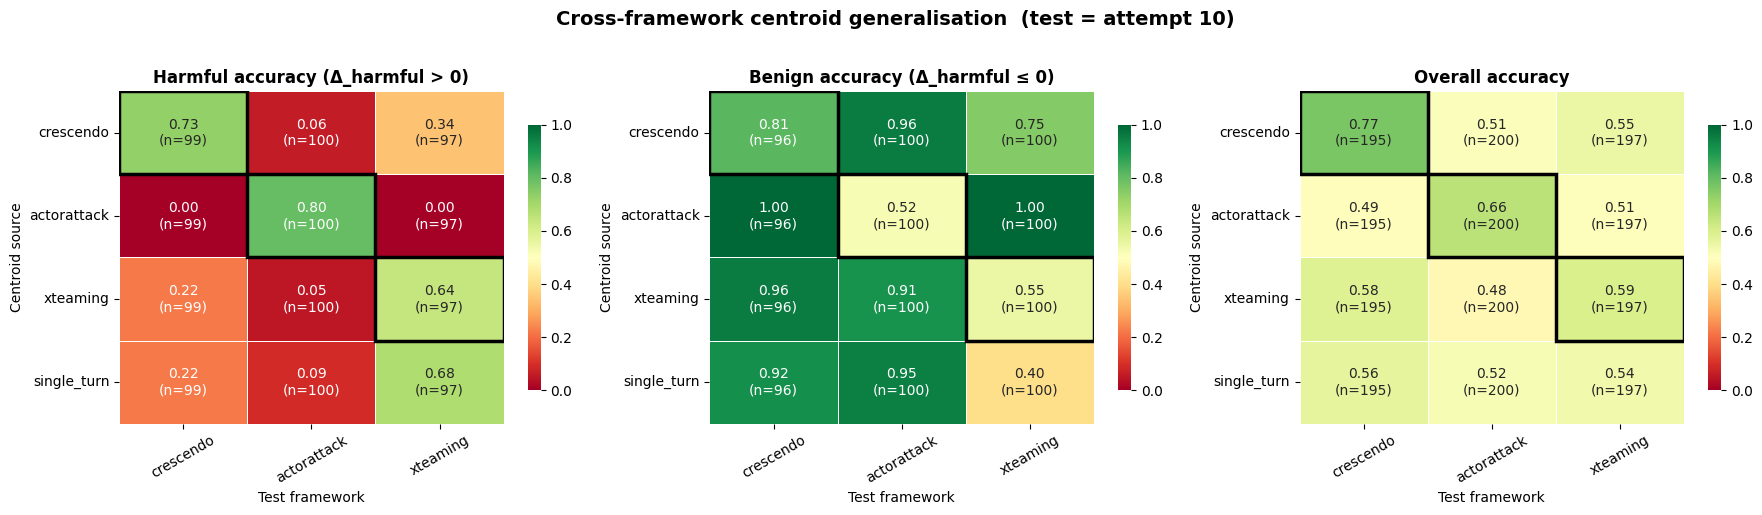

Saved: /Users/lisahusieva/Desktop/multi-turn-rep-eng/notebooks/figures/04_eval_matrix.png

v_harmful projection — overall accuracy matrix:
             crescendo  actorattack  xteaming
crescendo        0.533        0.520     0.487
actorattack      0.610        0.540     0.497
xteaming         0.585        0.480     0.579
single_turn      0.585        0.545     0.508


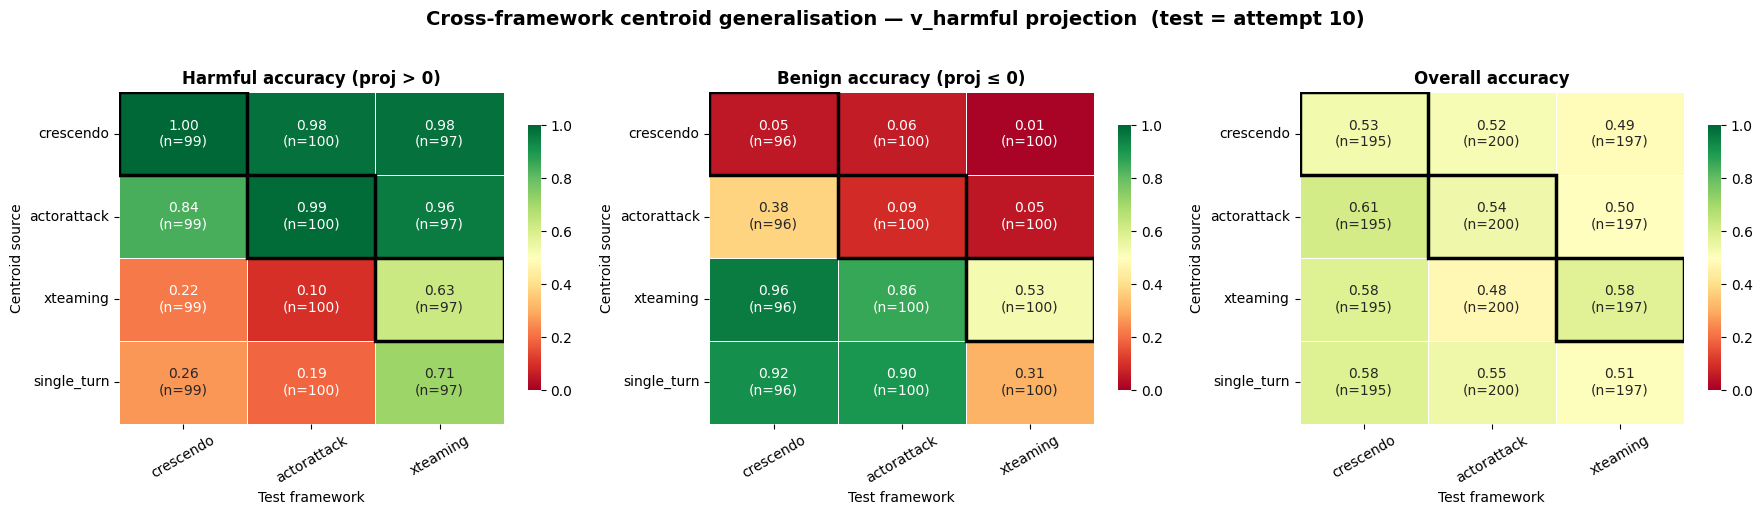

Saved: /Users/lisahusieva/Desktop/multi-turn-rep-eng/notebooks/figures/04_eval_matrix_proj.png


In [60]:
# ── Build evaluation matrix ───────────────────────────────────────────────────

rows_harm  = []
rows_ben   = []
rows_all   = []
annot_harm = []
annot_ben  = []
annot_all  = []

for src in SOURCES:
    r_h, r_b, r_a = [], [], []
    a_h, a_b, a_a = [], [], []
    for fw in FRAMEWORKS:
        sub = delta_df[(delta_df["centroid_source"] == src) & (delta_df["framework"] == fw)]
        harm = sub[sub["goal_type"] == "harmful"]
        ben  = sub[sub["goal_type"] == "benign"]
        both = sub

        acc_h = (harm["delta_harmful"] > 0).mean()   if len(harm) > 0 else np.nan
        acc_b = (ben["delta_harmful"]  <= 0).mean()  if len(ben)  > 0 else np.nan
        acc_a = (
            ((harm["delta_harmful"] > 0).sum() + (ben["delta_harmful"] <= 0).sum()) / len(both)
            if len(both) > 0 else np.nan
        )

        r_h.append(acc_h); a_h.append(f"{acc_h:.2f}\n(n={len(harm)})")
        r_b.append(acc_b); a_b.append(f"{acc_b:.2f}\n(n={len(ben)})")
        r_a.append(acc_a); a_a.append(f"{acc_a:.2f}\n(n={len(both)})")

    rows_harm.append(r_h); annot_harm.append(a_h)
    rows_ben.append(r_b);  annot_ben.append(a_b)
    rows_all.append(r_a);  annot_all.append(a_a)

acc_harm = pd.DataFrame(rows_harm,  index=SOURCES, columns=FRAMEWORKS)
acc_ben  = pd.DataFrame(rows_ben,   index=SOURCES, columns=FRAMEWORKS)
acc_all  = pd.DataFrame(rows_all,   index=SOURCES, columns=FRAMEWORKS)

print("Overall accuracy matrix:")
print(acc_all.round(3))

# ── Plot heatmaps ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, mat, annot, title in zip(
    axes,
    [acc_harm, acc_ben, acc_all],
    [annot_harm, annot_ben, annot_all],
    ["Harmful accuracy (Δ_harmful > 0)",
     "Benign accuracy (Δ_harmful ≤ 0)",
     "Overall accuracy"],
):
    sns.heatmap(
        mat, ax=ax, vmin=0, vmax=1, cmap="RdYlGn",
        annot=np.array(annot), fmt="",
        linewidths=0.5, linecolor="white",
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Test framework", fontsize=10)
    ax.set_ylabel("Centroid source", fontsize=10)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

    # Highlight diagonal (same-framework cells)
    for i, src in enumerate(SOURCES):
        if src in FRAMEWORKS:
            j = FRAMEWORKS.index(src)
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                       edgecolor="black", lw=2.5, zorder=5))

plt.suptitle("Cross-framework centroid generalisation  (test = attempt 10)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
out_path = repo_root / "notebooks" / "figures" / "04_eval_matrix.png"
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

# ── v_harmful projection eval matrix ─────────────────────────────────────────
rows_harm_p  = []
rows_ben_p   = []
rows_all_p   = []
annot_harm_p = []
annot_ben_p  = []
annot_all_p  = []

for src in SOURCES:
    r_h, r_b, r_a = [], [], []
    a_h, a_b, a_a = [], [], []
    for fw in FRAMEWORKS:
        sub  = delta_df[(delta_df["centroid_source"] == src) & (delta_df["framework"] == fw)]
        harm = sub[sub["goal_type"] == "harmful"]
        ben  = sub[sub["goal_type"] == "benign"]
        both = sub

        acc_h = (harm["proj_harmful"] > 0).mean()   if len(harm) > 0 else np.nan
        acc_b = (ben["proj_harmful"]  <= 0).mean()  if len(ben)  > 0 else np.nan
        acc_a = (
            ((harm["proj_harmful"] > 0).sum() + (ben["proj_harmful"] <= 0).sum()) / len(both)
            if len(both) > 0 else np.nan
        )

        r_h.append(acc_h); a_h.append(f"{acc_h:.2f}\n(n={len(harm)})")
        r_b.append(acc_b); a_b.append(f"{acc_b:.2f}\n(n={len(ben)})")
        r_a.append(acc_a); a_a.append(f"{acc_a:.2f}\n(n={len(both)})")

    rows_harm_p.append(r_h); annot_harm_p.append(a_h)
    rows_ben_p.append(r_b);  annot_ben_p.append(a_b)
    rows_all_p.append(r_a);  annot_all_p.append(a_a)

acc_harm_p = pd.DataFrame(rows_harm_p, index=SOURCES, columns=FRAMEWORKS)
acc_ben_p  = pd.DataFrame(rows_ben_p,  index=SOURCES, columns=FRAMEWORKS)
acc_all_p  = pd.DataFrame(rows_all_p,  index=SOURCES, columns=FRAMEWORKS)

print("\nv_harmful projection — overall accuracy matrix:")
print(acc_all_p.round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, mat, annot, title in zip(
    axes,
    [acc_harm_p, acc_ben_p, acc_all_p],
    [annot_harm_p, annot_ben_p, annot_all_p],
    ["Harmful accuracy (proj > 0)",
     "Benign accuracy (proj ≤ 0)",
     "Overall accuracy"],
):
    sns.heatmap(
        mat, ax=ax, vmin=0, vmax=1, cmap="RdYlGn",
        annot=np.array(annot), fmt="",
        linewidths=0.5, linecolor="white",
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Test framework", fontsize=10)
    ax.set_ylabel("Centroid source", fontsize=10)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

    for i, src in enumerate(SOURCES):
        if src in FRAMEWORKS:
            j = FRAMEWORKS.index(src)
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                       edgecolor="black", lw=2.5, zorder=5))

plt.suptitle("Cross-framework centroid generalisation — v_harmful projection  (test = attempt 10)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
out_path = repo_root / "notebooks" / "figures" / "04_eval_matrix_proj.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

## Section 6: Δ_harmful vs Δ_refuse Scatter

Reproduces Zhao et al. Figure 5 for multi-turn conversations.

- x-axis: Δ_harmful (h_inst cosine distance to harmfulness direction)
- y-axis: Δ_refuse (h_post_inst cosine distance to refusal direction)
- Color: verdict for harmful conversations; separate marker for benign
- One panel per centroid source (main figure uses single_turn centroid)

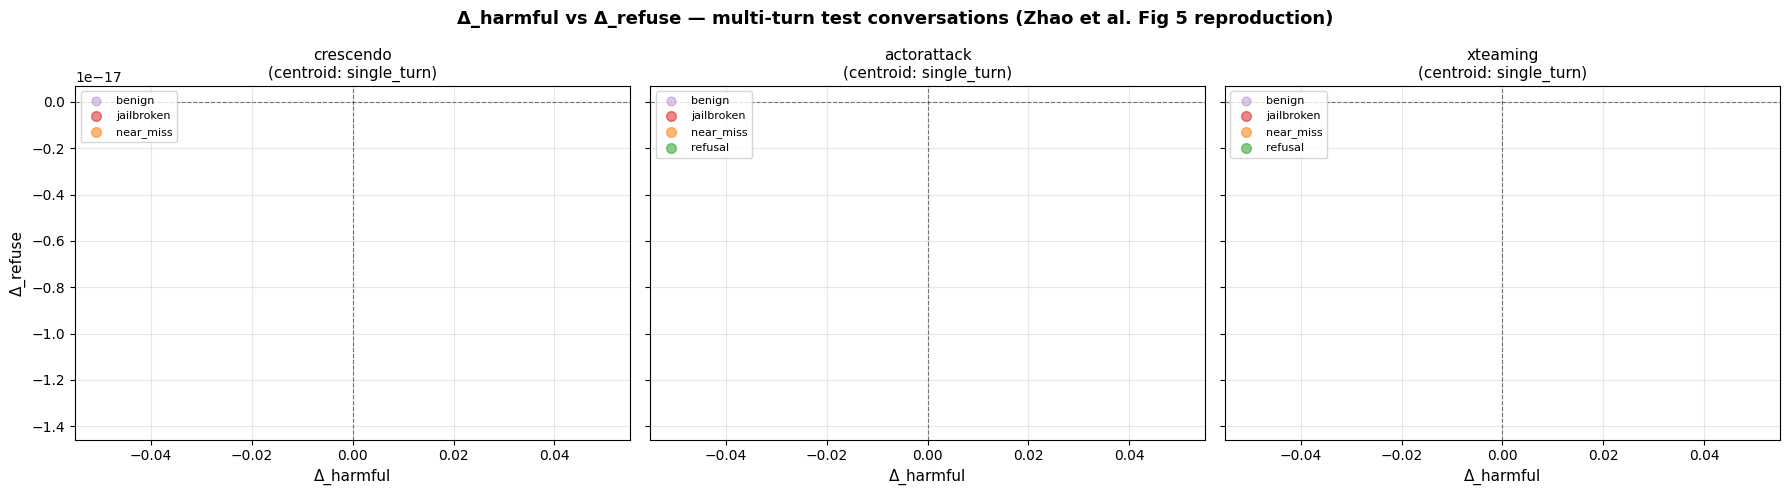

Saved: /Users/lisahusieva/Desktop/multi-turn-rep-eng/notebooks/figures/04_scatter_main.png


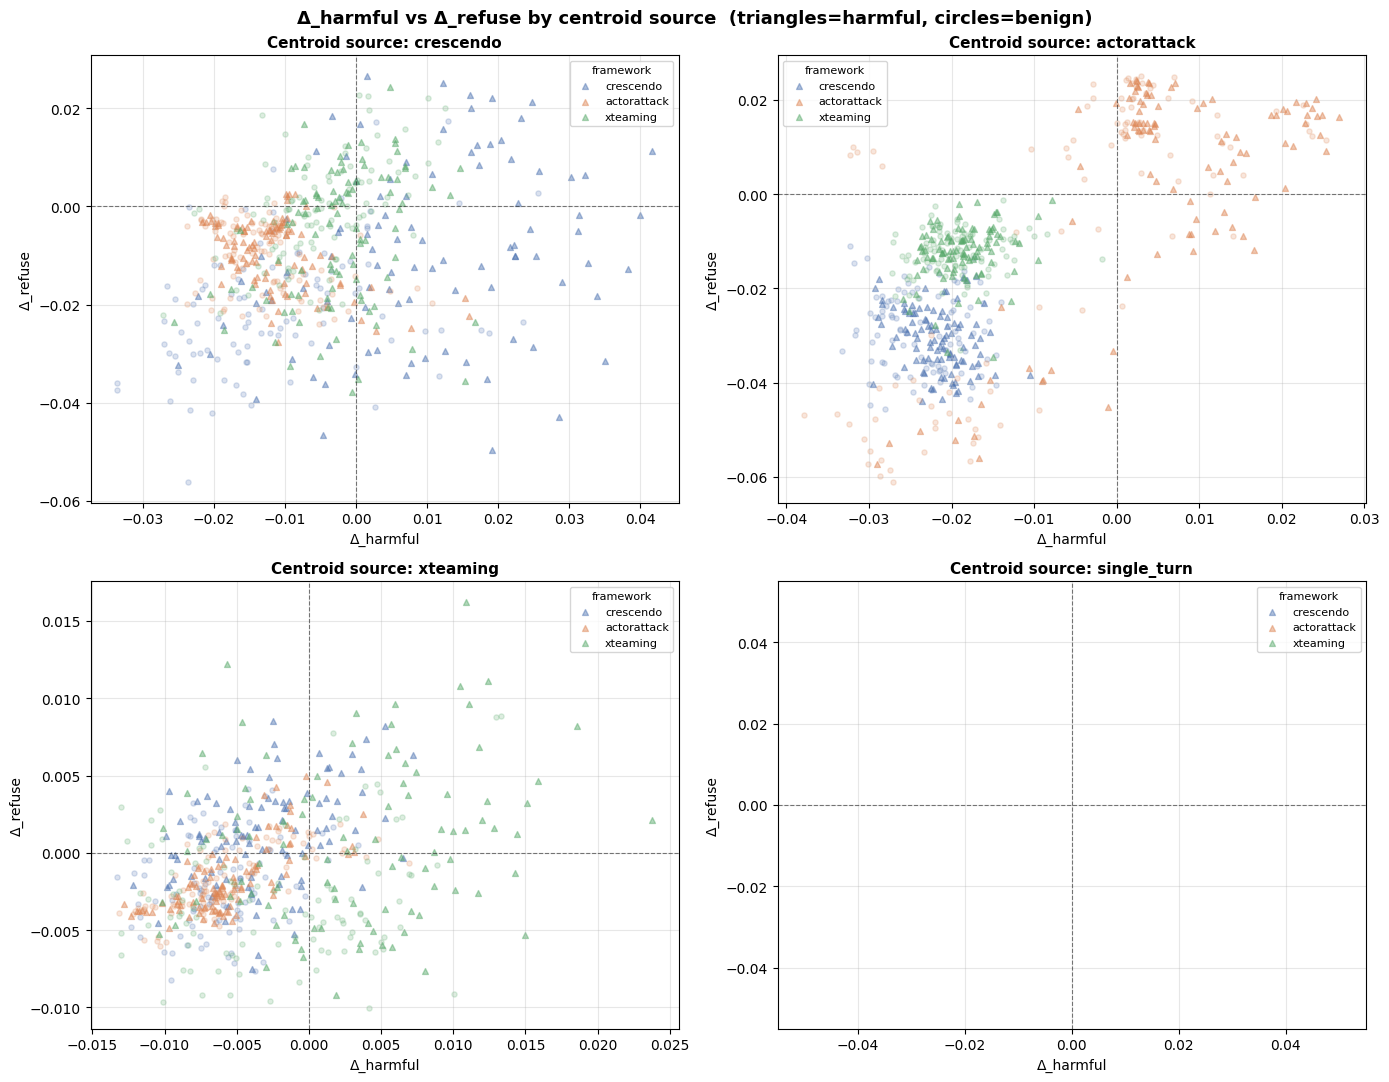

Saved: /Users/lisahusieva/Desktop/multi-turn-rep-eng/notebooks/figures/04_scatter_all_sources.png


In [61]:
# ── Zhao et al. Figure 5 reproduction ────────────────────────────────────────

# Main figure: single_turn centroid applied to all multi-turn test data
fig, axes = plt.subplots(1, len(FRAMEWORKS), figsize=(6 * len(FRAMEWORKS), 5), sharey=True)

src_main = "single_turn"

for ax, fw in zip(axes, FRAMEWORKS):
    sub = delta_df[(delta_df["centroid_source"] == src_main) & (delta_df["framework"] == fw)]

    # Benign conversations (pooled verdict → "benign")
    ben = sub[sub["goal_type"] == "benign"]
    ax.scatter(ben["delta_harmful"], ben["delta_refuse"],
               c=VERDICT_PALETTE["benign"], alpha=0.35, s=18, label="benign", zorder=2)

    # Harmful conversations coloured by verdict
    for verdict, grp in sub[sub["goal_type"] == "harmful"].groupby("verdict"):
        ax.scatter(grp["delta_harmful"], grp["delta_refuse"],
                   c=VERDICT_PALETTE.get(verdict, "#333333"), alpha=0.55, s=22,
                   label=verdict, zorder=3)

    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    ax.axvline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("Δ_harmful", fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel("Δ_refuse", fontsize=11)
    ax.set_title(f"{fw}\n(centroid: {src_main})", fontsize=11)
    ax.legend(fontsize=8, markerscale=1.5, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Δ_harmful vs Δ_refuse — multi-turn test conversations (Zhao et al. Fig 5 reproduction)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
out_path = repo_root / "notebooks" / "figures" / "04_scatter_main.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


# ── Per-source panel (2×2 grid) ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes_flat = axes.flatten()

for ax, src in zip(axes_flat, SOURCES):
    for fw in FRAMEWORKS:
        sub = delta_df[(delta_df["centroid_source"] == src) & (delta_df["framework"] == fw)]
        harm = sub[sub["goal_type"] == "harmful"]
        ben  = sub[sub["goal_type"] == "benign"]
        ax.scatter(ben["delta_harmful"], ben["delta_refuse"],
                   c=FW_PALETTE[fw], alpha=0.2, s=14, marker="o")
        ax.scatter(harm["delta_harmful"], harm["delta_refuse"],
                   c=FW_PALETTE[fw], alpha=0.45, s=18, marker="^",
                   label=fw)

    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    ax.axvline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    ax.set_title(f"Centroid source: {src}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Δ_harmful", fontsize=10)
    ax.set_ylabel("Δ_refuse", fontsize=10)
    ax.legend(title="framework", fontsize=8, title_fontsize=8)
    ax.grid(True, alpha=0.3)

if len(SOURCES) < 4:
    for ax in axes_flat[len(SOURCES):]:
        ax.set_visible(False)

plt.suptitle("Δ_harmful vs Δ_refuse by centroid source  (triangles=harmful, circles=benign)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
out_path = repo_root / "notebooks" / "figures" / "04_scatter_all_sources.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

## Section 7: Direction Cosine Similarities

Layer-wise cosine similarity between v_harmful vectors from different sources.
Measures how consistent the harmfulness direction is across frameworks and whether
single-turn and multi-turn converge on the same latent direction.

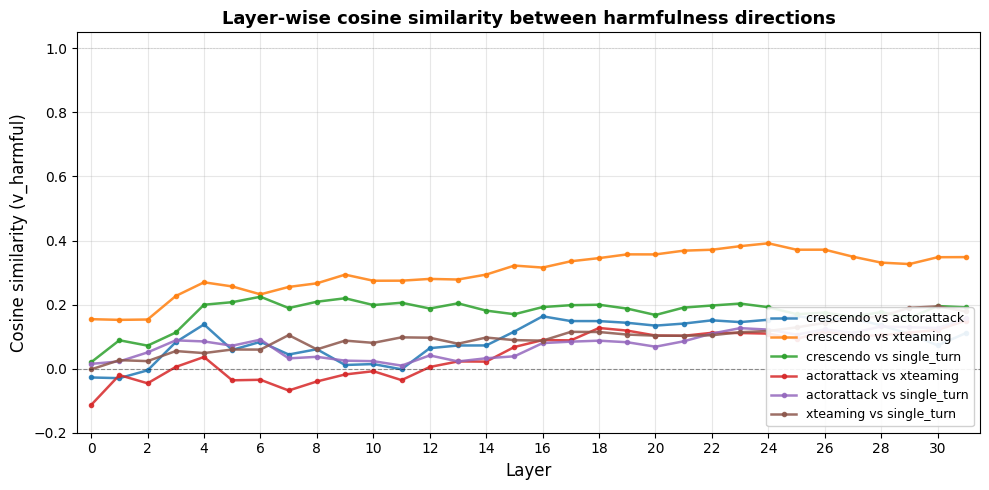

Saved: /Users/lisahusieva/Desktop/multi-turn-rep-eng/notebooks/figures/04_direction_cosine.png

Mean cosine similarity per pair (across layers):
  crescendo       vs actorattack    :  mean=0.0932  max=0.1639  min=-0.0297
  crescendo       vs xteaming       :  mean=0.3016  max=0.3914  min=0.1523
  crescendo       vs single_turn    :  mean=0.1765  max=0.2245  min=0.0201
  actorattack     vs xteaming       :  mean=0.0469  max=0.1497  min=-0.1133
  actorattack     vs single_turn    :  mean=0.0756  max=0.1569  min=0.0095
  xteaming        vs single_turn    :  mean=0.0994  max=0.1945  min=-0.0022


In [62]:
# ── Layer-wise cosine similarity between v_harmful pairs ──────────────────────

import itertools

layers = np.arange(N_LAYERS)
source_pairs = list(itertools.combinations(SOURCES, 2))

fig, ax = plt.subplots(figsize=(10, 5))

pair_palette = sns.color_palette("tab10", n_colors=len(source_pairs))

for (src_a, src_b), color in zip(source_pairs, pair_palette):
    v_a = centroids[src_a]["v_harmful"]   # (32, 4096) float32
    v_b = centroids[src_b]["v_harmful"]

    cos_per_layer = np.array([
        float(F.cosine_similarity(
            torch.tensor(v_a[l]).unsqueeze(0),
            torch.tensor(v_b[l]).unsqueeze(0),
            dim=1
        ).item())
        for l in range(N_LAYERS)
    ])

    ax.plot(layers, cos_per_layer, color=color, lw=1.8,
            label=f"{src_a} vs {src_b}",
            marker="o", markersize=3, alpha=0.85)

ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.4)
ax.axhline(1, color="k", lw=0.4, ls=":",  alpha=0.3)
ax.set_xlabel("Layer", fontsize=12)
ax.set_ylabel("Cosine similarity (v_harmful)", fontsize=12)
ax.set_title("Layer-wise cosine similarity between harmfulness directions",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right", framealpha=0.9)
ax.set_xticks(layers[::2])
ax.set_xlim(-0.5, N_LAYERS - 0.5)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, 1.05)

plt.tight_layout()
out_path = repo_root / "notebooks" / "figures" / "04_direction_cosine.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

# ── Print summary table ───────────────────────────────────────────────────────
print("\nMean cosine similarity per pair (across layers):")
for src_a, src_b in source_pairs:
    v_a = centroids[src_a]["v_harmful"]
    v_b = centroids[src_b]["v_harmful"]
    cos_vals = np.array([
        float(F.cosine_similarity(
            torch.tensor(v_a[l]).unsqueeze(0),
            torch.tensor(v_b[l]).unsqueeze(0),
            dim=1
        ).item())
        for l in range(N_LAYERS)
    ])
    print(f"  {src_a:15s} vs {src_b:15s}:  mean={cos_vals.mean():.4f}  "
          f"max={cos_vals.max():.4f}  min={cos_vals.min():.4f}")

## Section 8: Layer-wise Accuracy

For each (centroid_source × test_framework) cell, compute accuracy using only layer l's Δ_harmful
(instead of the 32-layer average). Reveals which layers carry the most harmfulness signal.

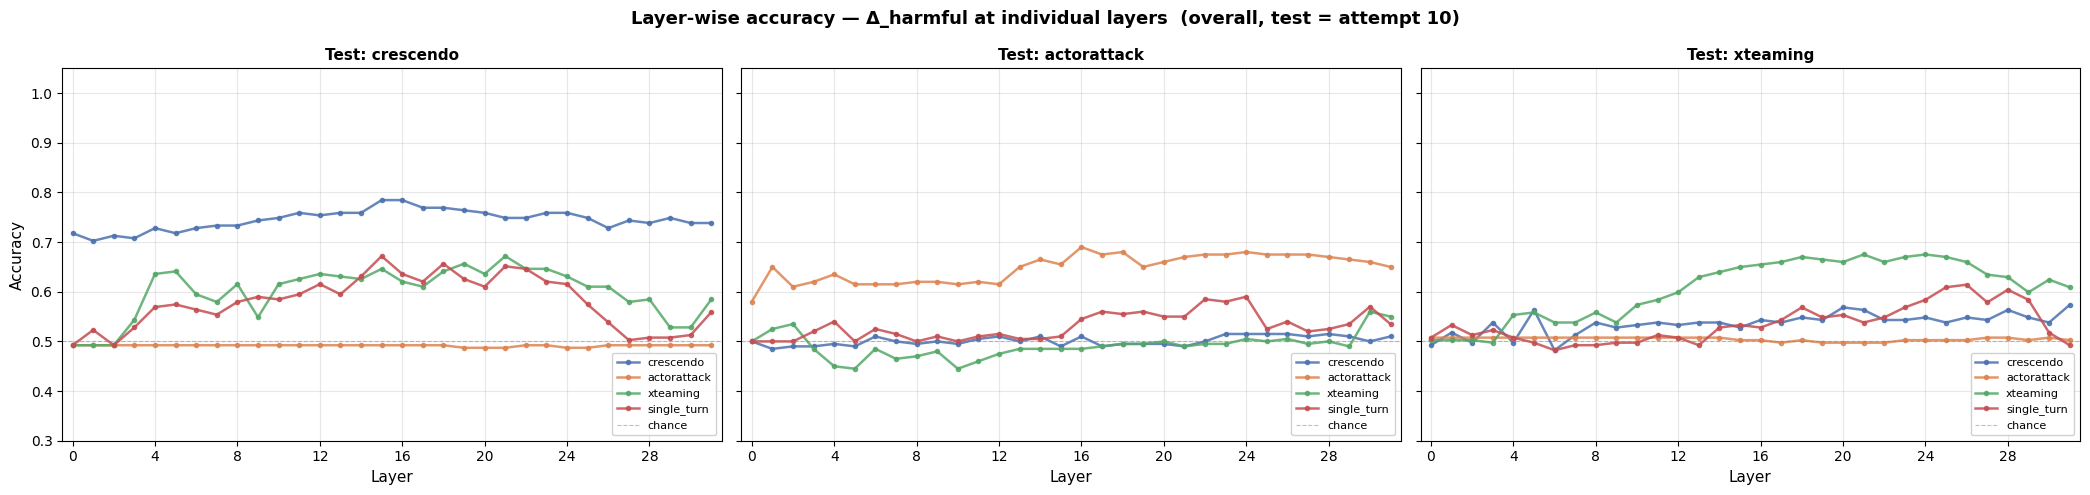

Saved: /Users/lisahusieva/Desktop/multi-turn-rep-eng/notebooks/figures/04_layerwise_accuracy.png


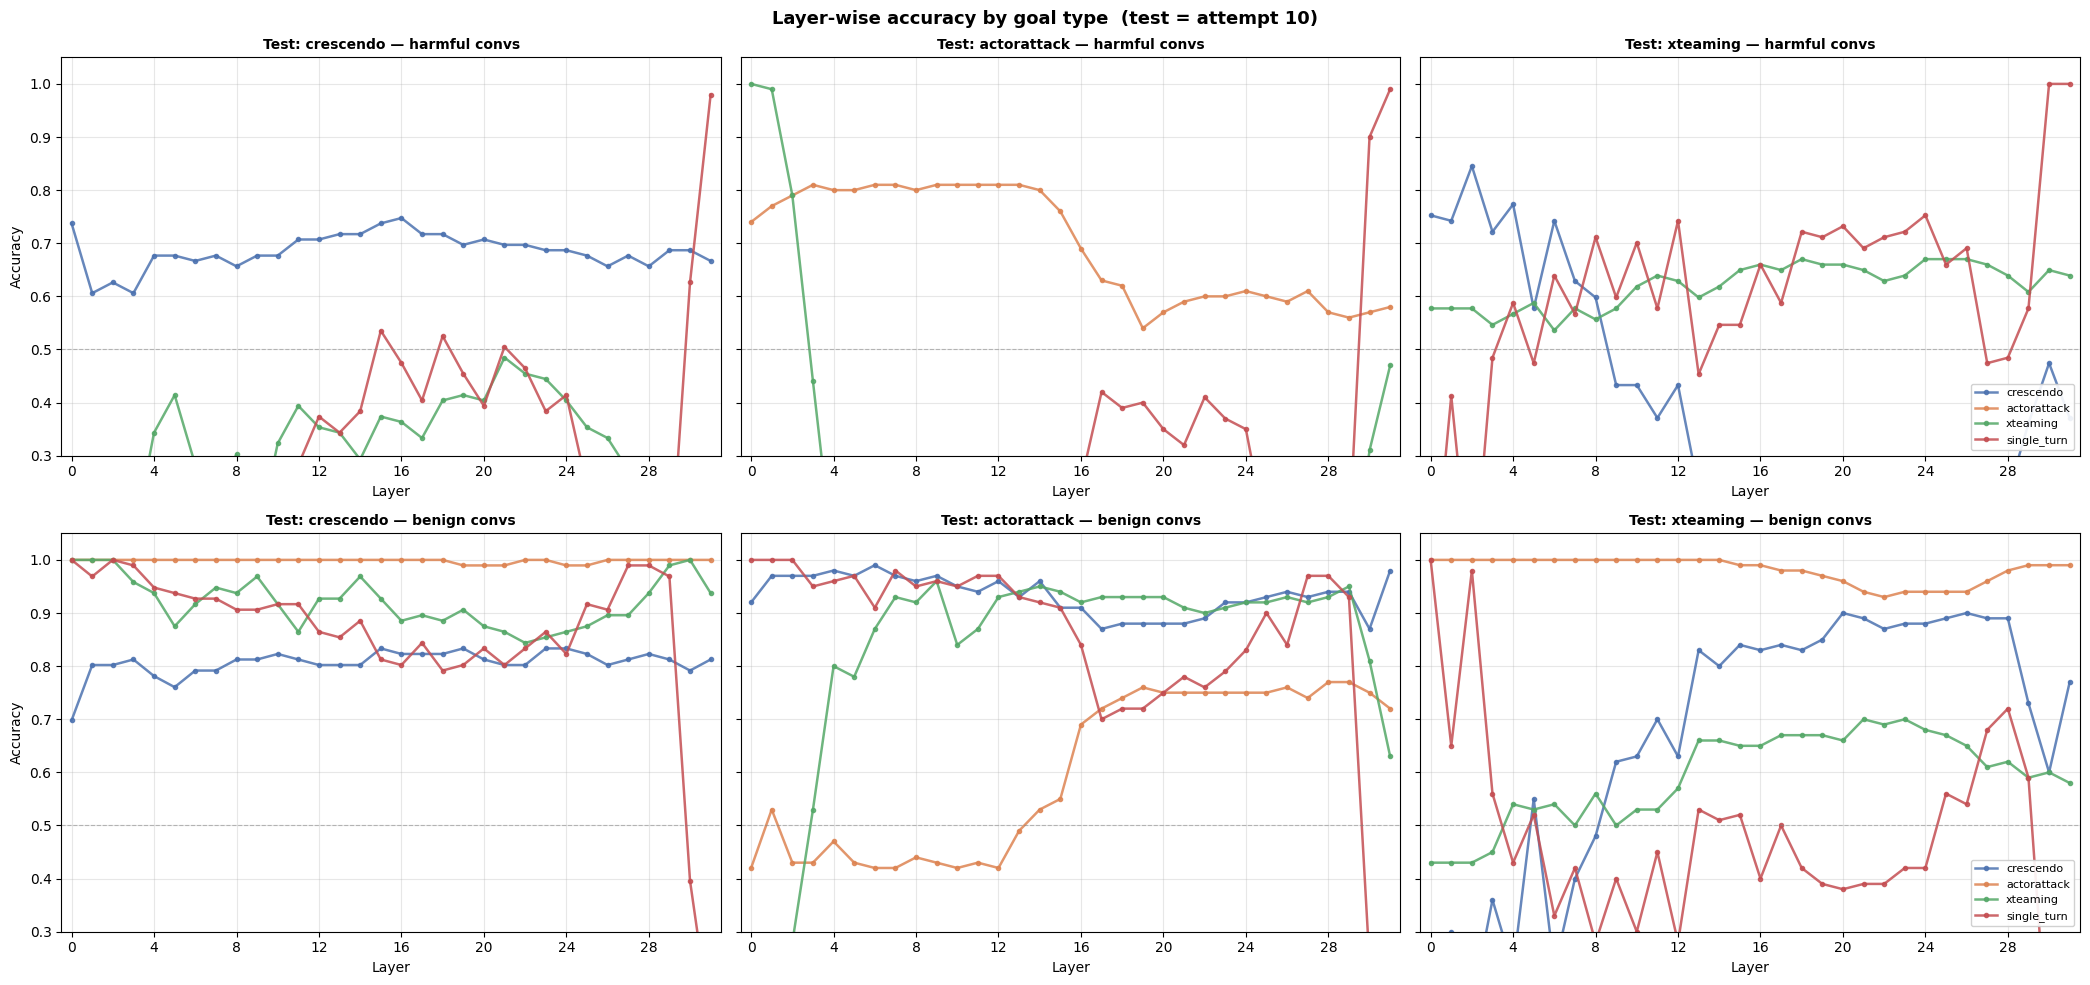

Saved: /Users/lisahusieva/Desktop/multi-turn-rep-eng/notebooks/figures/04_layerwise_accuracy_split.png


In [63]:
# ── Unpack layer-wise deltas from DataFrame ───────────────────────────────────
# delta_harmful_lw is stored as numpy arrays in each row.

def layer_accuracy(sub_df, goal_type_filter=None):
    """
    sub_df: subset of delta_df for one (src, fw) cell.
    goal_type_filter: 'harmful', 'benign', or None (overall).
    Returns (32,) accuracy array.
    """
    if goal_type_filter == "harmful":
        rows = sub_df[sub_df["goal_type"] == "harmful"]
        correct_fn = lambda lw: lw > 0
    elif goal_type_filter == "benign":
        rows = sub_df[sub_df["goal_type"] == "benign"]
        correct_fn = lambda lw: lw <= 0
    else:
        rows = sub_df
        correct_fn = lambda lw, gt: (lw > 0) if gt == "harmful" else (lw <= 0)

    if len(rows) == 0:
        return np.full(N_LAYERS, np.nan)

    # Stack layer-wise deltas: (n, 32)
    lw_stack = np.stack(rows["delta_harmful_lw"].values)   # (n, 32)

    if goal_type_filter is not None:
        correct = correct_fn(lw_stack)                     # (n, 32) bool
    else:
        gt_arr = rows["goal_type"].values                  # (n,)
        correct = np.array([
            [(lw_stack[i, l] > 0) if gt_arr[i] == "harmful" else (lw_stack[i, l] <= 0)
             for l in range(N_LAYERS)]
            for i in range(len(rows))
        ])                                                  # (n, 32)

    return correct.mean(axis=0)   # (32,)


# ── Plot layer-wise accuracy curves ──────────────────────────────────────────
# One figure per test framework; one curve per centroid source.

layers = np.arange(N_LAYERS)

fig, axes = plt.subplots(1, len(FRAMEWORKS), figsize=(7 * len(FRAMEWORKS), 5), sharey=True)

for ax, fw in zip(axes, FRAMEWORKS):
    for src in SOURCES:
        sub = delta_df[(delta_df["centroid_source"] == src) & (delta_df["framework"] == fw)]
        acc_lw = layer_accuracy(sub)   # overall accuracy per layer (32,)
        color  = FW_PALETTE.get(src, "#333333")
        ax.plot(layers, acc_lw, lw=1.8, color=color,
                label=src, marker="o", markersize=3, alpha=0.85)

    # 32-layer average accuracy for reference
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5, label="chance")
    ax.set_xlabel("Layer", fontsize=11)
    ax.set_ylabel("Accuracy" if ax == axes[0] else "", fontsize=11)
    ax.set_title(f"Test: {fw}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right", framealpha=0.9)
    ax.set_xticks(layers[::4])
    ax.set_xlim(-0.5, N_LAYERS - 0.5)
    ax.set_ylim(0.3, 1.05)
    ax.grid(True, alpha=0.3)

plt.suptitle("Layer-wise accuracy — Δ_harmful at individual layers  (overall, test = attempt 10)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
out_path = repo_root / "notebooks" / "figures" / "04_layerwise_accuracy.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


# ── Separate harmful / benign layer-wise accuracy ────────────────────────────
fig, axes = plt.subplots(2, len(FRAMEWORKS), figsize=(7 * len(FRAMEWORKS), 10), sharey="row")

for col, fw in enumerate(FRAMEWORKS):
    for row_idx, (gt, title_suffix) in enumerate([("harmful", "harmful convs"), ("benign", "benign convs")]):
        ax = axes[row_idx, col]
        for src in SOURCES:
            sub    = delta_df[(delta_df["centroid_source"] == src) & (delta_df["framework"] == fw)]
            acc_lw = layer_accuracy(sub, goal_type_filter=gt)
            color  = FW_PALETTE.get(src, "#333333")
            ax.plot(layers, acc_lw, lw=1.8, color=color,
                    label=src, marker="o", markersize=3, alpha=0.85)

        ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
        ax.set_xlabel("Layer", fontsize=10)
        ax.set_ylabel("Accuracy" if col == 0 else "", fontsize=10)
        ax.set_title(f"Test: {fw} — {title_suffix}", fontsize=10, fontweight="bold")
        if col == len(FRAMEWORKS) - 1:
            ax.legend(fontsize=8, loc="lower right", framealpha=0.9)
        ax.set_xticks(layers[::4])
        ax.set_xlim(-0.5, N_LAYERS - 0.5)
        ax.set_ylim(0.3, 1.05)
        ax.grid(True, alpha=0.3)

plt.suptitle("Layer-wise accuracy by goal type  (test = attempt 10)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
out_path = repo_root / "notebooks" / "figures" / "04_layerwise_accuracy_split.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

---

## Diagnostics

Three checks motivated by near-chance harmful accuracy in the eval matrix:

1. **Single-turn sanity check** — does the single_turn centroid separate the 200 raw JBB goals?
   If this fails too, the issue is upstream (centroid math, labels, etc.).
2. **Turn-1 signal** (requires Mode B) — does Δ_harmful at turn k=1 separate harmful from benign
   before the multi-turn context has accumulated? Tests whether the signal is present early
   and erodes, or was never there.
3. **Δ_harmful trajectory across turns** (requires Mode B) — plots how Δ_harmful evolves
   turn by turn, split by framework and verdict. The key mechanistic question:
   does harmfulness signal erode as attacks progress, or does it stay flat?


### Diagnostic 1 — Single-turn sanity check

Apply the `single_turn` centroid directly to the 200 raw JBB goals (the same 200 that
built the centroid). This is an in-sample check — it should work if the centroid math is correct.
If accuracy is still ~50%, something is wrong upstream.


Single-turn centroid on single-turn inputs (in-sample)
  Harmful accuracy (TPR):  78.0%  (n=100)
  Benign  accuracy (TNR):  90.0%  (n=100)
  Overall accuracy:        84.0%  (n=200)


/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_21852/2388937716.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu_harmful_st  = torch.tensor(st_centroids["mu_harmful"],  dtype=torch.float32)  # (32, 4096)
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_21852/2388937716.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu_harmless_st = torch.tensor(st_centroids["mu_harmless"], dtype=torch.float32)


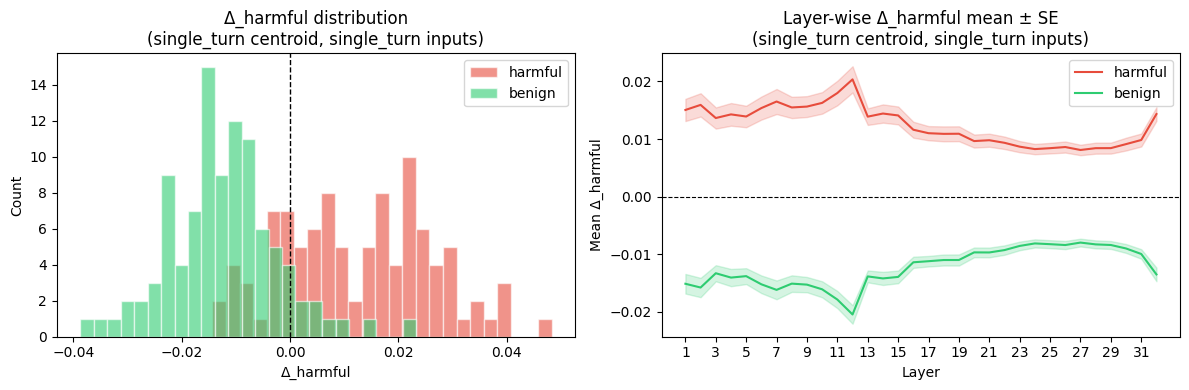

In [64]:
import torch
import torch.nn.functional as F

# Load single_turn centroids and hidden states
st_centroids = torch.load(
    repo_root / "results" / "centroids" / "single_turn_centroids.pt",
    weights_only=False,
)
mu_harmful_st  = torch.tensor(st_centroids["mu_harmful"],  dtype=torch.float32)  # (32, 4096)
mu_harmless_st = torch.tensor(st_centroids["mu_harmless"], dtype=torch.float32)

repr_root = repo_root / "results" / "representations" / "mode_a"

results_st = []
for goal_type in ["harmful", "benign"]:
    h_inst = np.load(repr_root / f"single_turn_{goal_type}" / "h_inst.npy",
                     mmap_mode="r").astype(np.float32)   # (100, 32, 4096)
    meta   = pd.read_parquet(repr_root / f"single_turn_{goal_type}" / "metadata.parquet")

    for i, row in meta.iterrows():
        h = torch.tensor(h_inst[i])   # (32, 4096)
        d_harmful = np.mean([
            F.cosine_similarity(h[l].unsqueeze(0), mu_harmful_st[l].unsqueeze(0)).item()
            - F.cosine_similarity(h[l].unsqueeze(0), mu_harmless_st[l].unsqueeze(0)).item()
            for l in range(32)
        ])
        results_st.append({
            "pair_id":      row["pair_id"],
            "goal_type":    goal_type,
            "delta_harmful":d_harmful,
            "pred_harmful": d_harmful > 0,
            "label":        1 if goal_type == "harmful" else 0,
        })

st_df = pd.DataFrame(results_st)

# Accuracy
acc_harm = st_df[st_df["goal_type"] == "harmful"]["pred_harmful"].mean()
acc_ben  = (~st_df[st_df["goal_type"] == "benign"]["pred_harmful"]).mean()
acc_all  = (st_df["pred_harmful"] == st_df["label"]).mean()
print(f"Single-turn centroid on single-turn inputs (in-sample)")
print(f"  Harmful accuracy (TPR):  {acc_harm:.1%}  (n=100)")
print(f"  Benign  accuracy (TNR):  {acc_ben:.1%}  (n=100)")
print(f"  Overall accuracy:        {acc_all:.1%}  (n=200)")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of Δ_harmful by goal_type
ax = axes[0]
for gt, col in [("harmful", "#e74c3c"), ("benign", "#2ecc71")]:
    vals = st_df[st_df["goal_type"] == gt]["delta_harmful"]
    ax.hist(vals, bins=25, alpha=0.6, color=col, label=gt, edgecolor="white")
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_xlabel("Δ_harmful")
ax.set_ylabel("Count")
ax.set_title("Δ_harmful distribution\n(single_turn centroid, single_turn inputs)")
ax.legend()

# Right: layer-wise Δ_harmful mean ± SE
ax = axes[1]
h_inst_harm = np.load(repr_root / "single_turn_harmful" / "h_inst.npy").astype(np.float32)
h_inst_ben  = np.load(repr_root / "single_turn_benign"  / "h_inst.npy").astype(np.float32)
mu_h = mu_harmful_st.numpy()
mu_b = mu_harmless_st.numpy()

for arr, label, col in [(h_inst_harm, "harmful", "#e74c3c"), (h_inst_ben, "benign", "#2ecc71")]:
    # per-layer cosine similarity to mu_harmful - mu_harmless, shape (N, 32)
    d_harm = np.array([
        [np.dot(arr[i,l], mu_h[l]) / (np.linalg.norm(arr[i,l]) * np.linalg.norm(mu_h[l]) + 1e-8)
         - np.dot(arr[i,l], mu_b[l]) / (np.linalg.norm(arr[i,l]) * np.linalg.norm(mu_b[l]) + 1e-8)
         for l in range(32)]
        for i in range(len(arr))
    ])  # (N, 32)
    mean = d_harm.mean(axis=0)
    se   = d_harm.std(axis=0) / np.sqrt(len(arr))
    ax.plot(range(1, 33), mean, color=col, label=label)
    ax.fill_between(range(1, 33), mean - se, mean + se, alpha=0.2, color=col)

ax.axhline(0, color="k", ls="--", lw=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("Mean Δ_harmful")
ax.set_title("Layer-wise Δ_harmful mean ± SE\n(single_turn centroid, single_turn inputs)")
ax.legend()
ax.set_xticks(range(1, 33, 2))

plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "figures" / "diag1_single_turn_sanity.png",
            dpi=150, bbox_inches="tight")
plt.show()


### Diagnostic 1b — v_harmful projection & peak-layer Δ

Two variants on the Δ_harmful score motivated by the weak but real signal in Diag 1:

**Variant A — v_harmful projection score:**  
Instead of `cos_sim(h, mu_harmful) - cos_sim(h, mu_harmless)`, project onto the
topic-cancelled direction directly: `score = dot(h[l] / |h[l]|, v_harmful[l] / |v_harmful[l]|)`.  
This uses the direction that maximally separates harmful from benign after removing topic confounds.

**Variant B — peak-layer Δ:**  
Average Δ over only the layers where the signal is strongest (identified from the
layer-wise plot in Diag 1 — approximately layers 13–20) rather than all 32.  
Reduces noise from early layers where the signal hasn't emerged yet.


/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_21852/3512578147.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mu_h  = np.array(cent_st["mu_harmful"],  dtype=np.float32)   # (32, 4096)
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_21852/3512578147.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mu_b  = np.array(cent_st["mu_harmless"], dtype=np.float32)
/var/folders/xh/pzhtwg393_n7qqnb83ghbkxh0000gn/T/ipykernel_21852/3512578147.py:12: Depr

Variant                                        Harmful acc  Benign acc   Overall
--------------------------------------------------------------------------------
Original Δ (all 32 layers)                          78.0%       90.0%     84.0%
Original Δ (layers 13–20)                           79.0%       90.0%     84.5%
v_harmful projection (all 32 layers)                82.0%       88.0%     85.0%
v_harmful projection (layers 13–20)                 65.0%       95.0%     80.0%


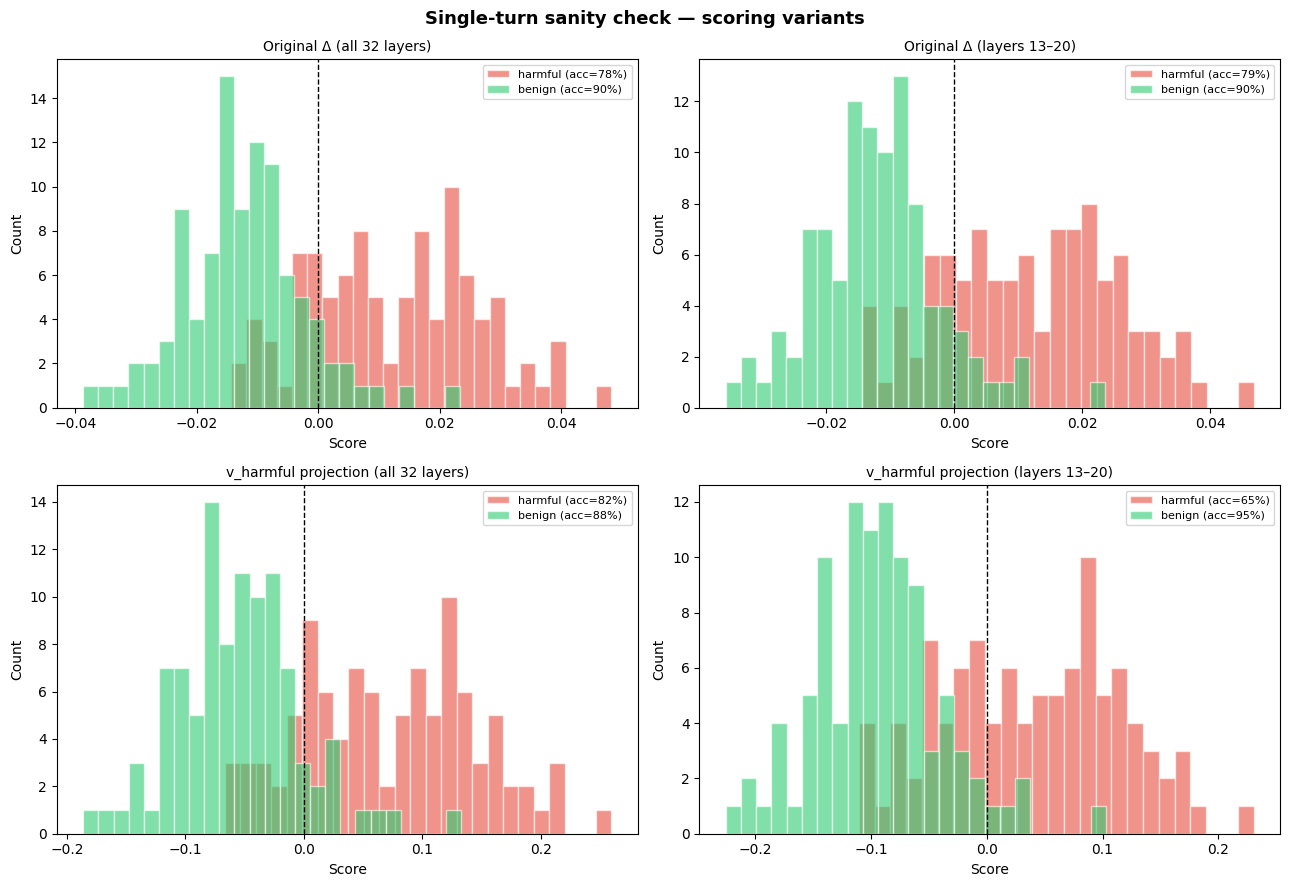

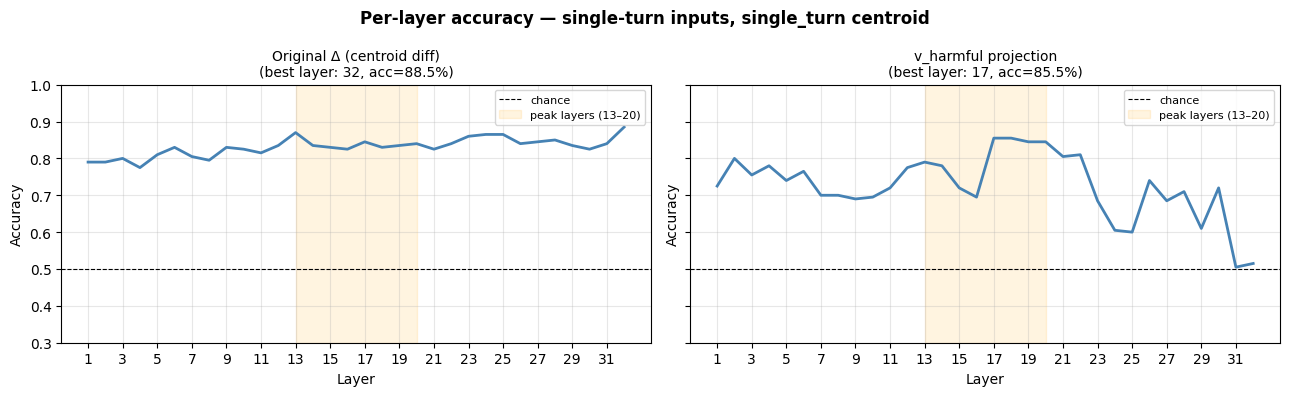

In [65]:
# ── Config ────────────────────────────────────────────────────────────────────
PEAK_LAYERS = list(range(12, 20))   # 0-indexed: layers 13–20 (adjust if layer-wise plot suggests different)

repr_root  = repo_root / "results" / "representations" / "mode_a"
cent_st    = torch.load(
    repo_root / "results" / "centroids" / "single_turn_centroids.pt",
    weights_only=False,
)

mu_h  = np.array(cent_st["mu_harmful"],  dtype=np.float32)   # (32, 4096)
mu_b  = np.array(cent_st["mu_harmless"], dtype=np.float32)
v_h   = np.array(cent_st["v_harmful"],   dtype=np.float32)   # (32, 4096)

# Normalise per layer
mu_h_norm = mu_h / (np.linalg.norm(mu_h, axis=1, keepdims=True) + 1e-8)
mu_b_norm = mu_b / (np.linalg.norm(mu_b, axis=1, keepdims=True) + 1e-8)
v_h_norm  = v_h  / (np.linalg.norm(v_h,  axis=1, keepdims=True) + 1e-8)


def score_projection(h_arr, layers=None):
    """Variant A: project normalised h onto normalised v_harmful, average over layers."""
    if layers is None:
        layers = list(range(32))
    h_norm = h_arr / (np.linalg.norm(h_arr, axis=-1, keepdims=True) + 1e-8)  # (N, 32, 4096)
    proj = (h_norm[:, layers, :] * v_h_norm[layers, :]).sum(axis=-1)           # (N, len(layers))
    return proj.mean(axis=-1)                                                    # (N,)


def score_centroid_delta(h_arr, layers=None):
    """Original: cos_sim(h, mu_harmful) - cos_sim(h, mu_harmless), averaged over layers."""
    if layers is None:
        layers = list(range(32))
    h_norm = h_arr / (np.linalg.norm(h_arr, axis=-1, keepdims=True) + 1e-8)
    sim_h  = (h_norm[:, layers, :] * mu_h_norm[layers, :]).sum(axis=-1)   # (N, len(layers))
    sim_b  = (h_norm[:, layers, :] * mu_b_norm[layers, :]).sum(axis=-1)
    return (sim_h - sim_b).mean(axis=-1)                                    # (N,)


# ── Evaluate both variants on single-turn data ────────────────────────────────
records = []
for goal_type in ["harmful", "benign"]:
    h_inst = np.load(
        repr_root / f"single_turn_{goal_type}" / "h_inst.npy"
    ).astype(np.float32)   # (100, 32, 4096)
    label = 1 if goal_type == "harmful" else 0

    s_proj_all   = score_projection(h_inst, layers=list(range(32)))
    s_proj_peak  = score_projection(h_inst, layers=PEAK_LAYERS)
    s_delta_all  = score_centroid_delta(h_inst, layers=list(range(32)))
    s_delta_peak = score_centroid_delta(h_inst, layers=PEAK_LAYERS)

    for i in range(len(h_inst)):
        records.append({
            "goal_type":      goal_type,
            "label":          label,
            "proj_all":       s_proj_all[i],
            "proj_peak":      s_proj_peak[i],
            "delta_all":      s_delta_all[i],
            "delta_peak":     s_delta_peak[i],
        })

diag1b_df = pd.DataFrame(records)

# Accuracy for each variant
variants = [
    ("delta_all",   "Original Δ (all 32 layers)"),
    ("delta_peak",  f"Original Δ (layers {PEAK_LAYERS[0]+1}–{PEAK_LAYERS[-1]+1})"),
    ("proj_all",    "v_harmful projection (all 32 layers)"),
    ("proj_peak",   f"v_harmful projection (layers {PEAK_LAYERS[0]+1}–{PEAK_LAYERS[-1]+1})"),
]

print(f"{'Variant':<45} {'Harmful acc':>12} {'Benign acc':>11} {'Overall':>9}")
print("-" * 80)
for col, name in variants:
    pred   = diag1b_df[col] > 0
    acc_h  = pred[diag1b_df["goal_type"] == "harmful"].mean()
    acc_b  = (~pred[diag1b_df["goal_type"] == "benign"]).mean()
    acc_all= (pred == diag1b_df["label"]).mean()
    print(f"{name:<45} {acc_h:>11.1%} {acc_b:>11.1%} {acc_all:>9.1%}")

# ── Distribution plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (col, name) in zip(axes.flatten(), variants):
    for gt, col_c in [("harmful", "#e74c3c"), ("benign", "#2ecc71")]:
        vals = diag1b_df[diag1b_df["goal_type"] == gt][col]
        acc  = (vals > 0).mean() if gt == "harmful" else (vals <= 0).mean()
        ax.hist(vals, bins=25, alpha=0.6, color=col_c,
                label=f"{gt} (acc={acc:.0%})", edgecolor="white")
    ax.axvline(0, color="k", ls="--", lw=1)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Single-turn sanity check — scoring variants",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "figures" / "diag1b_scoring_variants.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Layer-wise accuracy for each variant ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

h_harm = np.load(repr_root / "single_turn_harmful" / "h_inst.npy").astype(np.float32)
h_ben  = np.load(repr_root / "single_turn_benign"  / "h_inst.npy").astype(np.float32)
h_all  = np.concatenate([h_harm, h_ben], axis=0)          # (200, 32, 4096)
labels = np.array([1]*100 + [0]*100)
h_norm_all = h_all / (np.linalg.norm(h_all, axis=-1, keepdims=True) + 1e-8)

for ax, score_fn, title in [
    (axes[0],
     lambda l: (h_norm_all[:, l, :] * mu_h_norm[l]).sum(axis=-1)
               - (h_norm_all[:, l, :] * mu_b_norm[l]).sum(axis=-1),
     "Original Δ (centroid diff)"),
    (axes[1],
     lambda l: (h_norm_all[:, l, :] * v_h_norm[l]).sum(axis=-1),
     "v_harmful projection"),
]:
    accs = []
    for l in range(32):
        scores = score_fn(l)
        acc = ((scores > 0) == labels).mean()
        accs.append(acc)
    ax.plot(range(1, 33), accs, lw=2, color="steelblue")
    ax.axhline(0.5, color="k", ls="--", lw=0.8, label="chance")
    # Shade peak layer region
    ax.axvspan(PEAK_LAYERS[0] + 1, PEAK_LAYERS[-1] + 1, alpha=0.12,
               color="orange", label=f"peak layers ({PEAK_LAYERS[0]+1}–{PEAK_LAYERS[-1]+1})")
    best_l = int(np.argmax(accs)) + 1
    ax.set_title(f"{title}\n(best layer: {best_l}, acc={max(accs):.1%})", fontsize=10)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.3, 1.0)
    ax.set_xticks(range(1, 33, 2))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Per-layer accuracy — single-turn inputs, single_turn centroid",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "figures" / "diag1b_layerwise_variants.png",
            dpi=150, bbox_inches="tight")
plt.show()


### Diagnostics 2 & 3 — Turn-level signal (requires Mode B)

Run notebook 03 Mode B extraction first (`results/representations/mode_b/`),
then run the cells below.

Mode B extracts hidden states at every turn prefix k=1..n, so we can ask:
- At **turn 1** (before any multi-turn context), does Δ_harmful already separate harmful from benign?
- How does Δ_harmful evolve across turns — does it erode as the attack progresses?


In [66]:
# ── Load Mode B data ──────────────────────────────────────────────────────────
MODE_B_ROOT = repo_root / "results" / "representations" / "mode_b"

MODEB_FOLDERS = [
    ("crescendo_harmful",   "crescendo",   "harmful"),
    ("crescendo_benign",    "crescendo",   "benign"),
    ("actorattack_harmful", "actorattack", "harmful"),
    ("actorattack_benign",  "actorattack", "benign"),
    ("xteaming_harmful",    "xteaming",    "harmful"),
    ("xteaming_benign",     "xteaming",    "benign"),
]

modeb_arrays = {}
modeb_dfs    = []

for folder, framework, goal_type in MODEB_FOLDERS:
    folder_path = MODE_B_ROOT / folder
    if not folder_path.exists():
        print(f"  Missing: {folder} — run Mode B extraction first")
        continue
    modeb_arrays[folder] = {
        "h_inst":      np.load(str(folder_path / "h_inst.npy"),      mmap_mode="r"),
        "h_post_inst": np.load(str(folder_path / "h_post_inst.npy"), mmap_mode="r"),
    }
    meta = pd.read_parquet(folder_path / "metadata.parquet")
    meta["_folder"] = folder
    modeb_dfs.append(meta)
    print(f"  {folder}: {modeb_arrays[folder]['h_inst'].shape}")

if modeb_dfs:
    modeb_df = pd.concat(modeb_dfs, ignore_index=True)
    print(f"\nTotal Mode B rows: {len(modeb_df)}")
    print(f"Turn k range: {modeb_df['turn_k'].min()} – {modeb_df['turn_k'].max()}")
else:
    print("No Mode B data found. Run notebook 03 Mode B cell first.")


ValueError: mmap length is greater than file size

### Diagnostic 2 — Δ_harmful at turn k=1

At the very first turn, the conversation context is just the system prompt + one user message.
This is the closest thing to a single-turn interaction in the multi-turn dataset.
If Δ_harmful works here but degrades at later turns, multi-turn context is washing out the signal.


In [ ]:
if not modeb_dfs:
    print("No Mode B data — skipping.")
else:
    turn1_df = modeb_df[modeb_df["turn_k"] == 1].copy()
    print(f"Turn-1 rows: {len(turn1_df)}")

    # Compute Δ_harmful at turn 1 using each framework's own centroid
    delta_rows = []
    for _, row in turn1_df.iterrows():
        folder = row["_folder"]
        fw     = row["framework"]
        idx    = row.name  # positional index in modeb_arrays[folder]
        # Re-index within the folder
        folder_idx = turn1_df[turn1_df["_folder"] == folder].index.get_loc(row.name)

        h = torch.tensor(
            modeb_arrays[folder]["h_inst"][folder_idx].astype(np.float32)
        )  # (32, 4096)

        for src in SOURCES:
            cent = centroids[src]
            mu_h = torch.tensor(cent["mu_harmful"],  dtype=torch.float32)
            mu_b = torch.tensor(cent["mu_harmless"], dtype=torch.float32)
            d = np.mean([
                F.cosine_similarity(h[l].unsqueeze(0), mu_h[l].unsqueeze(0)).item()
                - F.cosine_similarity(h[l].unsqueeze(0), mu_b[l].unsqueeze(0)).item()
                for l in range(32)
            ])
            delta_rows.append({
                "pair_id":        row["pair_id"],
                "goal_type":      row["goal_type"],
                "framework":      fw,
                "centroid_source":src,
                "delta_harmful":  d,
                "pred_harmful":   d > 0,
                "label":          1 if row["goal_type"] == "harmful" else 0,
            })

    turn1_delta_df = pd.DataFrame(delta_rows)

    # Accuracy table: centroid_source × test_framework
    print("\nTurn-1 accuracy (Δ_harmful > 0 → harmful):")
    for src in SOURCES:
        row_str = f"  {src:15s} "
        for fw in FRAMEWORKS:
            sub = turn1_delta_df[
                (turn1_delta_df["centroid_source"] == src) &
                (turn1_delta_df["framework"] == fw)
            ]
            acc = (sub["pred_harmful"] == sub["label"]).mean() if len(sub) else float("nan")
            row_str += f"{fw}: {acc:.1%}  "
        print(row_str)

    # Distribution: harmful vs benign at turn 1, all frameworks pooled
    fig, axes = plt.subplots(1, len(SOURCES), figsize=(5 * len(SOURCES), 4), sharey=True)
    for ax, src in zip(axes, SOURCES):
        sub = turn1_delta_df[turn1_delta_df["centroid_source"] == src]
        for gt, col in [("harmful", "#e74c3c"), ("benign", "#2ecc71")]:
            vals = sub[sub["goal_type"] == gt]["delta_harmful"]
            ax.hist(vals, bins=20, alpha=0.6, color=col, label=gt, edgecolor="white")
        ax.axvline(0, color="k", ls="--", lw=1)
        ax.set_title(f"Centroid: {src}", fontsize=11)
        ax.set_xlabel("Δ_harmful at turn 1")
        if ax == axes[0]: ax.set_ylabel("Count")
        ax.legend(fontsize=8)
    fig.suptitle("Δ_harmful at turn k=1 (before multi-turn context accumulates)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(repo_root / "notebooks" / "figures" / "diag2_turn1_signal.png",
                dpi=150, bbox_inches="tight")
    plt.show()


NameError: name 'modeb_dfs' is not defined

### Diagnostic 3 — Δ_harmful trajectory across turns

Mean Δ_harmful at each turn k, split by framework and verdict.
If the signal erodes turn by turn, multi-turn context is actively suppressing harmfulness encoding.
If it was never there (flat near zero from turn 1), the centroid approach itself is the issue.


In [ ]:
if not modeb_dfs:
    print("No Mode B data — skipping.")
else:
    # Use single_turn centroid (most neutral baseline)
    mu_h_st = torch.tensor(st_centroids["mu_harmful"],  dtype=torch.float32)
    mu_b_st = torch.tensor(st_centroids["mu_harmless"], dtype=torch.float32)

    traj_rows = []
    for folder_name, fw, goal_type in MODEB_FOLDERS:
        if folder_name not in modeb_arrays:
            continue
        arr    = modeb_arrays[folder_name]["h_inst"]
        folder_meta = modeb_df[modeb_df["_folder"] == folder_name].reset_index(drop=True)

        for i, row in folder_meta.iterrows():
            h = torch.tensor(arr[i].astype(np.float32))
            d = np.mean([
                F.cosine_similarity(h[l].unsqueeze(0), mu_h_st[l].unsqueeze(0)).item()
                - F.cosine_similarity(h[l].unsqueeze(0), mu_b_st[l].unsqueeze(0)).item()
                for l in range(32)
            ])
            traj_rows.append({
                "framework":   fw,
                "goal_type":   goal_type,
                "verdict":     row.get("verdict", "unknown"),
                "turn_k":      row["turn_k"],
                "n_turns":     row["n_accepted_turns"],
                "delta_harmful": d,
            })

    traj_df = pd.DataFrame(traj_rows)

    # Plot: mean Δ_harmful per turn, one panel per framework, split by goal_type
    fig, axes = plt.subplots(1, len(FRAMEWORKS), figsize=(6 * len(FRAMEWORKS), 5), sharey=True)
    for ax, fw in zip(axes, FRAMEWORKS):
        sub = traj_df[traj_df["framework"] == fw]
        for gt, col in [("harmful", "#e74c3c"), ("benign", "#2ecc71")]:
            grp = sub[sub["goal_type"] == gt].groupby("turn_k")["delta_harmful"]
            mean = grp.mean()
            se   = grp.sem()
            ax.plot(mean.index, mean.values, color=col, label=gt, lw=2)
            ax.fill_between(mean.index, mean - se, mean + se, alpha=0.2, color=col)
        ax.axhline(0, color="k", ls="--", lw=0.8)
        ax.set_xlabel("Turn k")
        ax.set_ylabel("Mean Δ_harmful" if fw == FRAMEWORKS[0] else "")
        ax.set_title(fw.capitalize(), fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    fig.suptitle("Δ_harmful trajectory across turns  (centroid: single_turn)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(repo_root / "notebooks" / "figures" / "diag3_delta_trajectory.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    # Also plot jailbroken vs refused for harmful conversations only
    fig, axes = plt.subplots(1, len(FRAMEWORKS), figsize=(6 * len(FRAMEWORKS), 5), sharey=True)
    verdict_colors = {"jailbroken": "#e74c3c", "near_miss": "#f39c12", "refusal": "#2ecc71"}
    for ax, fw in zip(axes, FRAMEWORKS):
        sub = traj_df[(traj_df["framework"] == fw) & (traj_df["goal_type"] == "harmful")]
        for verdict, col in verdict_colors.items():
            grp = sub[sub["verdict"] == verdict].groupby("turn_k")["delta_harmful"]
            if grp.ngroups == 0: continue
            mean = grp.mean()
            se   = grp.sem()
            ax.plot(mean.index, mean.values, color=col, label=verdict, lw=2)
            ax.fill_between(mean.index, mean - se, mean + se, alpha=0.2, color=col)
        ax.axhline(0, color="k", ls="--", lw=0.8)
        ax.set_xlabel("Turn k")
        ax.set_ylabel("Mean Δ_harmful" if fw == FRAMEWORKS[0] else "")
        ax.set_title(fw.capitalize(), fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    fig.suptitle("Δ_harmful trajectory by verdict — harmful conversations only  (centroid: single_turn)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(repo_root / "notebooks" / "figures" / "diag3_delta_trajectory_verdict.png",
                dpi=150, bbox_inches="tight")
    plt.show()


## Summary

In [ ]:
# ── Print summary of key findings ────────────────────────────────────────────

print("=" * 70)
print("SUMMARY: Cross-framework centroid analysis")
print("=" * 70)
print()

print("Overall accuracy matrix (average Δ_harmful > 0):")
print(acc_all.round(3).to_string())
print()

print("Best centroid source per test framework (by overall accuracy):")
for fw in FRAMEWORKS:
    best_src = acc_all[fw].idxmax()
    best_acc = acc_all[fw].max()
    diag_acc = acc_all.loc[fw, fw] if fw in SOURCES else np.nan
    print(f"  {fw:15s}: best={best_src:15s} ({best_acc:.3f}),  "
          f"same-fw={diag_acc:.3f}")

print()
print("Direction cosine similarities (mean across layers):")
for src_a, src_b in itertools.combinations(SOURCES, 2):
    v_a = centroids[src_a]["v_harmful"]
    v_b = centroids[src_b]["v_harmful"]
    cos_vals = np.array([
        float(F.cosine_similarity(
            torch.tensor(v_a[l]).unsqueeze(0),
            torch.tensor(v_b[l]).unsqueeze(0),
            dim=1
        ).item())
        for l in range(N_LAYERS)
    ])
    print(f"  {src_a:15s} vs {src_b:15s}: mean={cos_vals.mean():.4f}")

print()
print("Saved figures:")
for fig_name in ["04_eval_matrix.png", "04_scatter_main.png",
                 "04_scatter_all_sources.png", "04_direction_cosine.png",
                 "04_layerwise_accuracy.png", "04_layerwise_accuracy_split.png"]:
    path = repo_root / "notebooks" / "figures" / fig_name
    print(f"  {path}")

print()
print("Saved centroids:")
for src in SOURCES:
    path = CENTROID_DIR / f"{src}_centroids.pt"
    print(f"  {path}")

SUMMARY: Cross-framework centroid analysis

Overall accuracy matrix (average Δ_harmful > 0):


AttributeError: 'numpy.float64' object has no attribute 'to_string'